# Pipeline reweightingu (supervised)

Łączy dwa istniejące kawałki: pipeline supervised (`summary.csv` / `curve_mean` / `curve_chi`)
i reweighting z blokowym jackknife'em.

Dla **każdego przejścia** i **każdego modelu supervised (30 cech, uncalibrated)** z `summary.csv`:

1. trenuje model na `TRAIN_30.npz` i liczy `P(d_j)` **tylko dla konfiguracji o `K0_close` / `Delta_close`**
   → `probabilites_for_reweighting/<TAG>_30_<PRZEJSCIE>.txt`,
2. robi reweighting tych `P(d_j)` po `K0` (A–C) albo po `delta` (A–B, B–Cb), z błędami z blokowego jackknife'a
   → `reweighting_results/<przejscie>/{curve_mean.csv, curve_chi.csv, summary.csv}`.



## Wzory

`P(konfig.) ~ Exp[(k0 + 6*delta)*N0 - K4*N4 - delta*N41]`, waga = iloraz dla nowych i starych parametrów:

**A–C** (przesuwamy `K0`) :

```
log w = (k0 - k0_ref) * (N0 - med0) - (fk4(k0) - fk4(k0_ref)) * (N4 - med4)
```

**A–B / B–Cb** (przesuwamy `delta`):

```
log w = 6*(delta - delta_ref) * (N0  - med0)
        - (fk4(delta) - fk4(delta_ref)) * (N4  - med4)
        - (delta - delta_ref) * (N41 - med5)
```

`fk4` = interpolacja liniowa `parametr -> K4`, budowana z plików `raw` (przedostatnia liczba w linii `Nso`).

## Obserwable i błędy

Jak w Twoim kodzie reweightingu:

```
mean     = sum(w*P) / sum(w)
variance = sum(w*P^2)/sum(w) - mean^2
chi      = variance / mean
```

Błędy: blokowy jackknife (`theta_jack = theta_hat - (B-1)*(theta_bar - theta_hat)`,
`se = sqrt((B-1) * mean((rep - theta_bar)^2))`), z wyborem `B` po **maksimum SE** — tak jak
`reweighted_jackknife_curve_max_error`. Różnica względem Twojej wersji: replikaty liczone są
z **sum blokowych**, a nie przez sklejanie tablic, więc jest to O(N) na punkt siatki zamiast O(B·N)
i można puścić pełną siatkę bez `except: pass`.

In [1]:
import os
import re
import time
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.optimize import brentq

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.3.5 | pandas 2.3.3


## 1. Konfiguracja

In [2]:
# --------------------------------------------------------------------------------------
# KONFIGURACJA
# --------------------------------------------------------------------------------------
ROOT = Path(".").resolve()          

TRANSITIONS = {
    #  folder    tag, rodzaj wzoru, krok siatki, orientacja P (True/False/"auto")
    "c_a":  dict(tag="AC",  kind="K0",    grid_step=0.001,   flip_p="auto"),
    # "a_b":  dict(tag="AB",  kind="DELTA", grid_step=0.0001,  flip_p="auto"),
    "b_cb": dict(tag="BCb", kind="DELTA", grid_step=0.00002, flip_p="auto"),
}
TRANSITIONS_TO_RUN = list(TRANSITIONS)      # np. ["c_a"] żeby puścić jedno przejście

PROB_DIR = ROOT / "probabilites_for_reweighting"
RW_DIR   = ROOT / "reweighting_results"

# --- dane -----------------------------------------------------------------------------
N_FEATURES   = 30
TRAIN_STRIDE = 10
FULL_STRIDE  = 1       

IDX_N0, IDX_N4, IDX_N41 = 0, 3, 4     # d[[All,1]], d[[All,4]], d[[All,5]]
CENTER = "median"                     # med0/med4/med5: "median" albo "mean"
FLIP_P = False                        # fallback, gdy w TRANSITIONS brak "flip_p"

# --- siatka parametru -----------------------------------------------------------------
GRID_MODE       = "table"    # "table" = pełny zakres z tabeli K4, "window" = okno wokół param_close
GRID_HALF_WIDTH = None       # szerokość okna dla GRID_MODE="window"
GRID_POINTS     = 201        # używane tylko gdy grid_step=None dla danego przejścia

# --- jackknife ------------------------------------------------------------------------
BLOCK_COUNTS     = list(range(2, 101))   # sekcja 3.4.3 pracy: wszystkie B = 2..100
BLOCK_SELECTION  = "max_se"  # "max_se" albo "fixed"
FIXED_BLOCK_COUNT = 20       # używane gdy BLOCK_SELECTION == "fixed"
REPORT           = "theta_jack"  # sekcja 3.4.3: raportujemy theta_jack (jak summarise_jackknife)

# --- pozostałe ------------------------------------------------------------------------
CHI_FOR_PEAK    = "variance"   # co uznajemy za "chi" przy szukaniu piku: "variance" albo "chi"
ESS_MIN_FRAC    = 0.01         # punkty z ESS/N poniżej -> pomijane przy szukaniu piku
PARAM_TOL       = 1e-6         # tolerancja dopasowania K0_close/Delta_close do wartości w FULL_30
AUTO_SCALER     = False        # nigdy nie standaryzujemy (StandardScaler wyłączony)

# --- modele pomijane w całym pipelinie -------------------------------------------------
# Warianty kNN różnią się wyłącznie implementacją wyszukiwania sąsiadów i dla ustalonego
# k zwracają identyczny wynik (sekcja 5.3 pracy), więc zostaje samo "kNN".
# Analogicznie zostaje sama "Logistic Regression" bez wariantu C = 0.00175.
MODEL_EXCLUDE = r"kd_tree|ball_tree|brute|c\s*=\s*0\.00175|standar|scal|z-?score|normaliz"

# --- orientacja P na WYKRESACH ---------------------------------------------------------
# PLOT_FLIP działa wyłącznie przy rysowaniu: zamienia P -> 1-P jednocześnie w krzywej
# z reweightingu i w punktach MC, więc obie nadal leżą na sobie. Pliki CSV zostają
# nietknięte i nie trzeba przeliczać pipeline'u - wystarczy puścić komórki z wykresami.
#
# Co jest niezmiennicze względem tej zamiany:
#   * punkt przecięcia z 0.5   (1-P przecina 0.5 tam samo co P),
#   * Var(1-P) = Var(P), a więc i położenie piku podatności,
#   * słupki błędu Jackknife.
# Nie jest niezmiennicza kolumna "chi" = Var/mean, ale pik liczymy z "variance"
# (CHI_FOR_PEAK), więc nie ma to wpływu na wyniki.
PLOT_FLIP = {
    "a_b": True,
    "c_a":  True,     # AC: rysujemy <Pr(d_j in C)>, malejące z kappa_0 (faza C przy 4.67)
    "b_cb": False,
}
PHASE_LABEL = {"c_a": "C", "b_cb": "C_b", "a_b": "A"}
RECOMPUTE_PROBS = True         # False = użyj gotowych .txt z P(d_j)
SAVE_PER_MODEL  = False        # True = dodatkowo osobne CSV na model
CRIT_BLOCK_COUNTS = list(range(2, 101))   # bloki do jackknife'a punktu krytycznego (bierzemy max SE)

# --- wykresy --------------------------------------------------------------------------
SHOW_MC_POINTS  = True         # nanieś punkty MC z pipeline'u supervised (curve_mean/curve_chi)
PLOT_MODEL_TAG  = {}           # np. {"c_a": "LR"} - model na wykresie "zoom"; domyślnie LR
ZOOM_PAD        = 0.35         # margines okna zoomu (ułamek szerokości obszaru przejścia)
CROSS_SIGMA     = 3            # półszerokość okna zoomu na P=0.5, w jednostkach 1 sigma
CROSS_PAD       = 0.30         # dodatkowy margines okna zoomu
SHOW_ESS_SHADE  = False        # cieniowanie obszaru ESS/N < ESS_MIN_FRAC na wykresach
#   UWAGA: to tylko warstwa graficzna. ESS_MIN_FRAC nadal ogranicza obszar, w którym
#   szukane jest maksimum podatności (maska ess_ok w run_transition), a kolumna
#   ess_frac w curve_mean.csv / curve_chi.csv pozostaje zapisana. Po wyłączeniu
#   cieniowania zakres wiarygodności trzeba opisać w podpisie rysunku:
#       _, m, _, _ = _read_results("c_a")
#       g = m[m["tag"] == "LR"]
#       ok = g.loc[g["ess_frac"] >= ESS_MIN_FRAC, "param"]
#       print(ok.min(), ok.max())
SAVE_PDF        = True
MAKE_PLOTS      = True

PROB_DIR.mkdir(exist_ok=True)
RW_DIR.mkdir(exist_ok=True)
print("ROOT:", ROOT)

ROOT: /home/mariuszoslaw/uni/masters


## 2. Diagnostyka struktury katalogów

In [3]:
RESULTS_DIR = ROOT / "Results" / "SUPERVISED"


TRANSITION_NAMES = {
    "c_a": "AC",
    "a_b": "AB",
    "b_cb": "BCb",
}


def transition_paths(folder: str) -> dict:
    base = ROOT / folder

    transition_name = TRANSITION_NAMES[folder]

    summary = (
        RESULTS_DIR
        / transition_name
        / f"{transition_name}_summary.csv"
    )

    return {
        "base": base,
        "raw": base / "data" / "raw",
        "processed": base / "data" / "processed",

        "full": base / "data" / "processed" / "FULL_30.npz",
        "train": base / "data" / "processed" / "TRAIN_30.npz",

        "summary": summary,
    }


def describe_layout():

    for folder in TRANSITIONS:

        p = transition_paths(folder)

        raw_files = (
            sorted(p["raw"].glob("vto-*.out"))
            if p["raw"].exists()
            else []
        )

        print(f"[{folder}]")

        print(
            f"   raw/        : "
            f"{len(raw_files)} plików  ({p['raw']})"
        )

        print(
            f"   FULL_30.npz : "
            f"{'OK' if p['full'].exists() else 'BRAK'}"
        )

        print(
            f"   TRAIN_30.npz: "
            f"{'OK' if p['train'].exists() else 'BRAK'}"
        )

        print(
            f"   summary     : "
            f"{'OK' if p['summary'].exists() else 'BRAK'} "
            f"({p['summary']})"
        )

        print()


describe_layout()


# --- pliki z pipeline'u supervised: Results/SUPERVISED/<NAZWA>/<NAZWA>_curve_<which>.csv ---
def mc_curve_path(folder: str, which: str = "mean") -> Path:
    """which: 'mean' albo 'chi'."""
    name = TRANSITION_NAMES[folder]
    return RESULTS_DIR / name / f"{name}_curve_{which}.csv"


def describe_mc_files():
    for folder in TRANSITIONS:
        print(f"[{folder}]")
        for which in ("mean", "chi"):
            p = mc_curve_path(folder, which)
            print(f"   curve_{which:5s}: {'OK  ' if p.exists() else 'BRAK'} {p}")
        print()


describe_mc_files()


[c_a]
   raw/        : 20 plików  (/home/mariuszoslaw/uni/masters/c_a/data/raw)
   FULL_30.npz : OK
   TRAIN_30.npz: OK
   summary     : OK (/home/mariuszoslaw/uni/masters/Results/SUPERVISED/AC/AC_summary.csv)

[b_cb]
   raw/        : 12 plików  (/home/mariuszoslaw/uni/masters/b_cb/data/raw)
   FULL_30.npz : OK
   TRAIN_30.npz: OK
   summary     : OK (/home/mariuszoslaw/uni/masters/Results/SUPERVISED/BCb/BCb_summary.csv)

[c_a]
   curve_mean : OK   /home/mariuszoslaw/uni/masters/Results/SUPERVISED/AC/AC_curve_mean.csv
   curve_chi  : OK   /home/mariuszoslaw/uni/masters/Results/SUPERVISED/AC/AC_curve_chi.csv

[b_cb]
   curve_mean : OK   /home/mariuszoslaw/uni/masters/Results/SUPERVISED/BCb/BCb_curve_mean.csv
   curve_chi  : OK   /home/mariuszoslaw/uni/masters/Results/SUPERVISED/BCb/BCb_curve_chi.csv



## 3. `K4` z plików `raw` + interpolacja `fk4`

Parametr z nazwy pliku (`vto-4.77-...` → `K0`; `vto-4.80--0.1080-...` → `delta=-0.1080`;
`vto-2.2-0.0360-...` → `delta=0.0360`), `K4` = przedostatnia liczba w linii `Nso`


In [4]:
RE_K0    = re.compile(r"vto-([+-]?\d+(?:\.\d+)?)")
RE_DELTA = re.compile(r"vto-[+-]?\d+(?:\.\d+)?-(-?\d+(?:\.\d+)?)")


def extract_parameter_from_filename(filename, kind: str) -> float:
    name = Path(filename).name
    rx = RE_K0 if kind == "K0" else RE_DELTA
    m = rx.match(name)
    if m is None:
        raise ValueError(f"Nie mogę wyciągnąć parametru ({kind}) z nazwy: {name}")
    return float(m.group(1))


def extract_k4_from_raw(filepath, n_check: int = 10) -> float:
    k4_values = []
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("#"):
                line = line[1:].strip()
            if line.startswith("Nso"):
                k4_values.append(float(line.split()[-2]))
                if len(k4_values) >= n_check:
                    break
    if not k4_values:
        raise ValueError(f"Brak linii 'Nso' w pliku: {filepath}")
    if not np.allclose(k4_values, k4_values[0], rtol=0, atol=1e-12):
        raise ValueError(f"K4 nie jest stałe w pliku {filepath}: {k4_values}")
    return k4_values[0]


def build_k4_table(raw_dir: Path, kind: str) -> pd.DataFrame:
    files = sorted(p for p in raw_dir.glob("vto-*.out") if p.is_file())
    if not files:
        raise FileNotFoundError(f"Brak plików raw w {raw_dir}")

    rows = [dict(parameter=extract_parameter_from_filename(fp, kind),
                 K4=extract_k4_from_raw(fp),
                 file=fp.name) for fp in files]
    df = pd.DataFrame(rows).sort_values("parameter").reset_index(drop=True)

    if df["parameter"].duplicated().any():      # np. warianty '-L.out' dla tego samego parametru
        grp = df.groupby("parameter")["K4"]
        spread = grp.max() - grp.min()
        if (spread > 1e-9).any():
            print("   UWAGA: różne K4 dla tego samego parametru:\n", spread[spread > 1e-9])
        df = (df.groupby("parameter", as_index=False)
                .agg(K4=("K4", "mean"), file=("file", lambda s: " | ".join(s)))
                .sort_values("parameter").reset_index(drop=True))
    return df


def build_fk4(k4_table: pd.DataFrame):
    return interp1d(k4_table["parameter"].to_numpy(float),
                    k4_table["K4"].to_numpy(float),
                    kind="linear", bounds_error=True)

## 4. `FULL_30.npz` / `TRAIN_30.npz`

Klucz parametru (`K0` albo `Delta`) wykrywany automatycznie.

In [5]:
PARAM_KEYS = {"K0": ["K0", "k0", "K0_full"], "DELTA": ["Delta", "delta", "Delta_full"]}


def load_transition_data(folder: str, kind: str) -> dict:
    p = transition_paths(folder)
    full = np.load(p["full"], allow_pickle=True)
    train = np.load(p["train"], allow_pickle=True)

    key = next((k for k in PARAM_KEYS[kind] if k in full.files), None)
    if key is None:
        raise KeyError(f"{p['full'].name}: brak klucza parametru, dostępne: {full.files}")

    X_full = full["X"][::FULL_STRIDE]                                  # oryginalny dtype (RAM)
    param_full = np.asarray(full[key], dtype=np.float64)[::FULL_STRIDE]

    X_train = np.asarray(train["X"], dtype=np.float64)[::TRAIN_STRIDE]
    y_train = np.asarray(train["y"])[::TRAIN_STRIDE]
    keep = np.array([v is not None for v in y_train])                  # y bywa object z None
    X_train, y_train = X_train[keep], y_train[keep].astype(int)

    assert X_full.shape[1] == N_FEATURES, f"FULL ma {X_full.shape[1]} cech"
    assert X_train.shape[1] == N_FEATURES, f"TRAIN ma {X_train.shape[1]} cech"

    print(f"   FULL : X={X_full.shape}, '{key}' -> {len(np.unique(param_full))} wartości")
    print(f"   TRAIN: X={X_train.shape}, klasy={np.unique(y_train)}")
    return dict(X_full=X_full, param_full=param_full, param_key=key,
                X_train=X_train, y_train=y_train)


def select_configs(param_full: np.ndarray, param_close: float):
    """Konfiguracje o parametrze == K0_close / Delta_close (odpowiednik mask = (K0_full == k0_ref))."""
    mask = np.isclose(param_full, param_close, rtol=0, atol=PARAM_TOL)
    if not mask.any():
        uniq = np.unique(param_full)
        nearest = float(uniq[np.argmin(np.abs(uniq - param_close))])
        print(f"   UWAGA: brak konfiguracji dla {param_close}; biorę najbliższą {nearest}")
        mask = np.isclose(param_full, nearest, rtol=0, atol=PARAM_TOL)
        param_close = nearest
    return mask, float(param_close)

## 5. `summary.csv` → lista modeli

Czytane są wszystkie pliki `*summary*.csv` z folderu przejścia i sklejane, a potem filtrowane:
`n_features == 30` i `calibration == "uncalibrated"`. Kolumna z punktem odniesienia to `K0_close` / `Delta_close`


In [6]:
COL_OVERRIDE = {}   # np. {"c_a": dict(model="model", close="K0_close", features="n_features")}

MODEL_COLS   = ["model", "model_name", "name", "classifier", "estimator"]
CLOSE_COLS   = ["k0_close", "delta_close", "param_close", "closest_k0", "closest_delta"]
FEATURE_COLS = ["n_features", "features", "n_feat", "feature_count"]
CALIB_COLS   = ["calibration", "calibrated", "is_calibrated", "calib"]
FSET_COLS    = ["feature_set", "featureset", "fset"]


def pick_col(df, candidates, contains=()):
    norm = {str(c).strip().lower().replace(" ", "_"): c for c in df.columns}
    for cand in candidates:
        if cand in norm:
            return norm[cand]
    for key, orig in norm.items():
        if any(sub in key for sub in contains):
            return orig
    return None


def is_calibrated(value) -> bool:
    """'uncalibrated' -> False, 'calibrated'/True/1 -> True."""
    if isinstance(value, str):
        v = value.strip().lower()
        if "uncalib" in v or v in {"false", "no", "nie", "0", "none", ""}:
            return False
        return ("calib" in v) or v in {"true", "yes", "tak", "1", "isotonic", "sigmoid"}
    try:
        return bool(int(value))
    except (TypeError, ValueError):
        return bool(value)


CRIT_COLS     = ["k0_crit", "delta_crit", "lambda_crit", "param_crit", "crit"]
CRIT_ERR_COLS = ["k0_crit_err", "delta_crit_err", "lambda_crit_err",
                 "param_crit_err", "crit_err"]


def pick_crit_cols(df):
    """(kolumna wartości, kolumna błędu) dla punktu krytycznego z interpolacji liniowej.

    Nie używa pick_col(contains=("crit",)), bo "K0_crit" i "K0_crit_err" obie zawierają
    "crit" i dopasowanie po fragmencie potrafi trafić w błąd zamiast w wartość.
    """
    norm = {str(c).strip().lower().replace(" ", "_"): c for c in df.columns}
    SUFFIXES = ("_err", "_error", "_sigma", "_b", "_n")

    c_err = next((norm[k] for k in CRIT_ERR_COLS if k in norm), None)
    if c_err is None:
        c_err = next((orig for key, orig in norm.items()
                      if "crit" in key and key.endswith(("_err", "_error", "_sigma"))), None)

    c_val = next((norm[k] for k in CRIT_COLS if k in norm), None)
    if c_val is None:
        c_val = next((orig for key, orig in norm.items()
                      if "crit" in key and not key.endswith(SUFFIXES)
                      and "close" not in key), None)
    return c_val, c_err


def load_summary_models(folder: str) -> pd.DataFrame:
    """summary.csv -> model, calibration, param_close, crit_interp, crit_interp_err."""
    path = transition_paths(folder)["summary"]
    if not path.exists():
        raise FileNotFoundError(f"[{folder}] brak pliku summary: {path}")

    df = pd.read_csv(path)
    ov = COL_OVERRIDE.get(folder, {})
    c_model = ov.get("model")       or pick_col(df, MODEL_COLS, contains=("model", "classif"))
    c_close = ov.get("close")       or pick_col(df, CLOSE_COLS, contains=("close",))
    c_feat  = ov.get("features")    or pick_col(df, FEATURE_COLS, contains=("featur",))
    c_cal   = ov.get("calibrated")  or pick_col(df, CALIB_COLS, contains=("calib",))
    c_fset  = ov.get("feature_set") or pick_col(df, FSET_COLS, contains=("feature_set",))
    c_crit, c_crit_err = pick_crit_cols(df)

    print(f"   {path.name}: model={c_model!r}, close={c_close!r}, "
          f"features={c_feat!r}, calibration={c_cal!r}")
    print(f"   {' ' * len(path.name)}  krytyczny (interpolacja): {c_crit!r} +- {c_crit_err!r}")
    if c_model is None or c_close is None:
        raise KeyError(f"[{folder}] nie rozpoznałem kolumn model/close w {path}: "
                       f"{list(df.columns)} - uzupełnij COL_OVERRIDE['{folder}']")
    if c_crit is None:
        print("   UWAGA: brak kolumny z punktem krytycznym z interpolacji "
              "-> wykres porównawczy będzie pusty")

    sub = df.copy()
    n_all = len(sub)

    if c_feat is not None:
        sub = sub[(pd.to_numeric(sub[c_feat], errors="coerce") == N_FEATURES).to_numpy()]
    elif c_fset is not None:
        sub = sub[(sub[c_fset].astype(str).str.strip() == str(N_FEATURES)).to_numpy()]
    n_feat = len(sub)

    if c_cal is not None and not sub.empty:
        sub = sub[~sub[c_cal].map(is_calibrated).to_numpy(dtype=bool)]
    if not sub.empty:
        names = sub[c_model].astype(str).str.lower()
        sub = sub[~names.str.contains("calibrat|isotonic|sigmoid", regex=True).to_numpy(dtype=bool)]

    n_cal = len(sub)
    if MODEL_EXCLUDE and not sub.empty:
        drop = (sub[c_model].astype(str).str.lower()
                .str.contains(MODEL_EXCLUDE, regex=True, na=False).to_numpy(dtype=bool))
        if drop.any():
            print(f"   pominięte przez MODEL_EXCLUDE: "
                  f"{', '.join(sorted(sub.loc[drop, c_model].astype(str)))}")
        sub = sub[~drop]

    print(f"   wiersze: {n_all} -> {n_feat} ({N_FEATURES} cech) -> {n_cal} (uncalibrated) "
          f"-> {len(sub)} (po MODEL_EXCLUDE)")
    if sub.empty:
        raise ValueError(f"[{folder}] po filtrach nie został żaden model ({path})")

    models = pd.DataFrame({
        "model": sub[c_model].astype(str),
        "calibration": (sub[c_cal].astype(str) if c_cal is not None else "uncalibrated"),
        "param_close": pd.to_numeric(sub[c_close], errors="coerce"),
        "crit_interp": (pd.to_numeric(sub[c_crit], errors="coerce") if c_crit else np.nan),
        "crit_interp_err": (pd.to_numeric(sub[c_crit_err], errors="coerce") if c_crit_err else np.nan),
        "source": path.name,
    })
    models = (models.dropna(subset=["param_close"])
                    .drop_duplicates(subset=["model"])
                    .reset_index(drop=True))
    print(f"   modele: {', '.join(models['model'])}")
    return models


## 6. Rejestr modeli i tagi

Rejestr odtwarza dokładnie słownik `models` z Twojego pipeline supervised; nazwy spoza rejestru
przechodzą przez dopasowanie heurystyczne, a nierozpoznane są wypisywane i pomijane.

In [7]:
def _norm(name: str) -> str:
    return re.sub(r"\s+", " ", str(name).strip().lower())
 
 
# metoda kalibracji SVM: "sigmoid" (Platt) albo "isotonic"
SVM_CALIBRATION = "sigmoid"
SVM_CALIBRATION_CV = 5
 
 
def _svm_rbf():
    """SVC bez predict_proba dawał P ściśnięte wokół 0.5 (std_P = 0.04, span 0.28),
    bo run_supervised_pipeline liczyło 1/(1+exp(-decision_function)) z marginesów
    rzędu 0.1. CalibratedClassifierCV daje prawdziwe prawdopodobieństwa."""
    return CalibratedClassifierCV(SVC(kernel="rbf"),
                                  method=SVM_CALIBRATION,
                                  cv=SVM_CALIBRATION_CV)
 
 
MODEL_REGISTRY = {
    "logistic regression":             lambda: LogisticRegression(max_iter=2000),
    "logistic regression c = 0.00175": lambda: LogisticRegression(C=0.00175),
    "decision tree":                   lambda: DecisionTreeClassifier(random_state=0),
    "random forest":                   lambda: RandomForestClassifier(n_estimators=200, random_state=0),
    "gradient boosted trees":          lambda: GradientBoostingClassifier(random_state=0),
    "knn":                             lambda: KNeighborsClassifier(n_jobs=-1),
    "svm (rbf)":                       _svm_rbf,
    "neural network":                  lambda: CalibratedClassifierCV(MLPClassifier(hidden_layer_sizes=(50, 50),
                                                             max_iter=500, random_state=0),method=SVM_CALIBRATION,
                                  cv=SVM_CALIBRATION_CV),
}
 
 
# --- modele trenowane ze standaryzacją poznajemy po nazwie -----------------------------
SCALER_PATTERNS = r"standar|scal|z-?score|normaliz"
 
 
def needs_scaler(model_name: str) -> bool:
    """'kNN kd_tree standarization' -> True (pipeline dostanie StandardScaler).
    Przy AUTO_SCALER = False standaryzacja jest wyłączona dla wszystkich modeli."""
    return AUTO_SCALER and bool(re.search(SCALER_PATTERNS, _norm(model_name)))
 
 
def build_estimator(model_name: str):
    """Nazwa z summary.csv -> estymator sklearn. None = nierozpoznany (pomijamy)."""
    n = _norm(model_name)
 
    if n in MODEL_REGISTRY:
        return MODEL_REGISTRY[n]()
 
    stripped = re.sub(SCALER_PATTERNS, " ", n).strip()
    stripped = re.sub(r"\s+", " ", stripped)
    if stripped in MODEL_REGISTRY:            # np. "knn kd_tree standarization"
        return MODEL_REGISTRY[stripped]()
    if re.search(r"calibrat|isotonic|sigmoid", n):
        return None
 
    # --- dopasowanie heurystyczne dla nazw spoza rejestru ---
    if "logistic" in n or re.match(r"^lr\b", n):
        m = re.search(r"c\s*=\s*([0-9.eE+-]+)", n)
        return LogisticRegression(C=float(m.group(1))) if m else LogisticRegression(max_iter=2000)
 
    if "random forest" in n or "randomforest" in n or re.match(r"^rf\b", n):
        m = re.search(r"n_estimators\s*=?\s*(\d+)", n)
        return RandomForestClassifier(n_estimators=int(m.group(1)) if m else 200, random_state=0)
 
    if "gradient" in n or "gbt" in n or "boost" in n:
        return GradientBoostingClassifier(random_state=0)
 
    if "decision tree" in n or re.match(r"^dt\b", n):
        if "hiper" in n or "hyper" in n:
            return DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=0)
        return DecisionTreeClassifier(random_state=0)
 
    if "knn" in n or "nearest" in n:
        m = re.search(r"(\d+)", n)
        algo = next((a for a in ("kd_tree", "ball_tree", "brute") if a in n), "auto")
        return KNeighborsClassifier(n_neighbors=int(m.group(1)) if m else 5,
                                    weights="distance" if "distance" in n else "uniform",
                                    algorithm=algo, n_jobs=-1)
 
    if "svm" in n or "svc" in n:
        return _svm_rbf()                     # ta sama kalibracja co w rejestrze
 
    if "neural" in n or "mlp" in n or re.match(r"^nn\b", n):
        return MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=500)
 
    return None
 
 
BASE_TAGS = [
    (r"logistic\s*regression|^lr\b", "LR"),
    (r"random\s*forest|^rf\b", "RF"),
    (r"gradient\s*boost(?:ed|ing)?|gbt", "GBT"),
    (r"decision\s*tree|^dt\b", "DT"),
    (r"k?\s*-?\s*nn|k\s*-?\s*nearest\s*neighbou?rs?", "KNN"),
    (r"svm|svc", "SVM"),
    (r"neural\s*network|mlp|^nn\b", "NN"),
]
FILLER = r"\b(trees?|classifier|clf|model|rbf|prob|probability|true)\b"
 
 
def make_tag(model_name: str) -> str:
    """'Logistic Regression C = 0.00175' -> 'LR-c000175'  =>  plik LR-c000175_30_AC.txt"""
    n = _norm(model_name)
    base, pattern = "MODEL", None
    for pat, tag in BASE_TAGS:
        if re.search(pat, n):
            base, pattern = tag, pat
            break
    rest = re.sub(pattern, " ", n) if pattern else n
    rest = re.sub(FILLER, " ", rest)
    rest = re.sub(r"[^0-9a-z]+", "", rest)
    return f"{base}-{rest}" if rest else base
 
 
def assign_tags(models: pd.DataFrame) -> pd.DataFrame:
    models = models.copy()
    tags, seen = [], {}
    for t in models["model"].map(make_tag):
        seen[t] = seen.get(t, 0) + 1
        tags.append(t if seen[t] == 1 else f"{t}{seen[t]}")
    models["tag"] = tags
    return models
 

## 7. `P(d_j)` — trening na TRAIN, predykcja tylko dla `K0_close` / `Delta_close`

In [8]:
def build_model(base_model, scale: bool = False):
    steps = ([("scaler", StandardScaler())] if scale else []) + [("clf", base_model)]
    return Pipeline(steps)


def run_supervised_pipeline(model, X_train, y_train, X_sel):
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    if hasattr(model, "predict_proba"):
        P_B = model.predict_proba(X_sel)[:, 1]
    else:
        scores = model.decision_function(X_sel)
        P_B = 1.0 / (1.0 + np.exp(-scores))
    return float(train_score), np.asarray(P_B, dtype=np.float64)


def prob_path(tag: str, trans_tag: str) -> Path:
    return PROB_DIR / f"{tag}_{N_FEATURES}_{trans_tag}.txt"


def compute_probabilities(folder, cfg, data, models) -> pd.DataFrame:
    rows, unknown = [], []

    for _, row in models.iterrows():
        name, tag = row["model"], row["tag"]
        base_model = build_estimator(name)
        if base_model is None:
            unknown.append(name)
            continue

        mask, param_close = select_configs(data["param_full"], float(row["param_close"]))
        X_sel = np.asarray(data["X_full"][mask], dtype=np.float64)
        out_path = prob_path(tag, cfg["tag"])

        if (not RECOMPUTE_PROBS) and out_path.exists():
            P = np.loadtxt(out_path)
            if P.shape[0] != X_sel.shape[0]:
                raise ValueError(f"{out_path.name}: {P.shape[0]} wartości vs {X_sel.shape[0]} konfiguracji")
            train_score = np.nan
            print(f"   [{tag:14s}] wczytane z {out_path.name} (n={len(P)})")
        else:
            t0 = time.perf_counter()
            scale = needs_scaler(name)
            train_score, P = run_supervised_pipeline(
                build_model(base_model, scale=scale), data["X_train"], data["y_train"], X_sel)
            np.savetxt(out_path, P, fmt="%.18f")
            print(f"   [{tag:14s}] {name}{' +scaler' if scale else ''}: "
                  f"param_close={param_close}, n={len(P)}, "
                  f"train_acc={train_score:.4f}, mean(P)={P.mean():.4f}  "
                  f"({time.perf_counter()-t0:.1f}s)")

        rows.append(dict(transition=cfg["tag"], folder=folder, tag=tag, model=name,
                         calibration=row["calibration"], param_key=data["param_key"],
                         param_close=param_close, n_configs=int(mask.sum()),
                         train_acc=train_score, prob_file=out_path.name,
                         crit_interp=row.get("crit_interp", np.nan),
                         crit_interp_err=row.get("crit_interp_err", np.nan)))

    if unknown:
        print(f"   POMINIĘTE (nierozpoznane w build_estimator): {unknown}")
    return pd.DataFrame(rows)


### Podgląd: co z `summary.csv` trafi do pipeline'u


In [9]:

def preview_models(folder: str) -> pd.DataFrame:
    models = assign_tags(load_summary_models(folder))
    rows = []
    for _, r in models.iterrows():
        est = build_estimator(r["model"])
        rows.append(dict(
            folder=folder,
            model=r["model"],
            tag=r["tag"],
            plik=f"{r['tag']}_{N_FEATURES}_{TRANSITIONS[folder]['tag']}.txt",
            param_close=r["param_close"],
            estymator=repr(est) if est is not None else "NIEROZPOZNANY",
            scaler=needs_scaler(r["model"]),
        ))
    return pd.DataFrame(rows)


preview = pd.concat([preview_models(f) for f in TRANSITIONS_TO_RUN], ignore_index=True)
with pd.option_context("display.max_colwidth", 90):
    display(preview)

missing = preview[preview["estymator"] == "NIEROZPOZNANY"]
if not missing.empty:
    print("DO UZUPEŁNIENIA w MODEL_REGISTRY:", sorted(set(missing["model"])))


   AC_summary.csv: model='model', close='K0_close', features='n_features', calibration='calibration'
                   krytyczny (interpolacja): 'K0_crit' +- 'K0_crit_err'
   pominięte przez MODEL_EXCLUDE: Logistic Regression C = 0.00175, kNN ball_tree, kNN kd_tree
   wiersze: 60 -> 20 (30 cech) -> 10 (uncalibrated) -> 7 (po MODEL_EXCLUDE)
   modele: Logistic Regression, Decision Tree, Random Forest, Gradient Boosted Trees, kNN, SVM (RBF), Neural Network
   BCb_summary.csv: model='model', close='Delta_close', features='n_features', calibration='calibration'
                    krytyczny (interpolacja): 'Delta_crit' +- 'Delta_crit_err'
   pominięte przez MODEL_EXCLUDE: Logistic Regression C = 0.00175, kNN ball_tree, kNN kd_tree
   wiersze: 60 -> 20 (30 cech) -> 10 (uncalibrated) -> 7 (po MODEL_EXCLUDE)
   modele: Logistic Regression, Decision Tree, Random Forest, Gradient Boosted Trees, kNN, SVM (RBF), Neural Network


,folder,model,tag,plik,param_close,estymator,scaler
0,c_a,Logistic Regression,LR,LR_30_AC.txt,4.7800,LogisticRegression(max_iter=2000),False
1,c_a,Decision Tree,DT,DT_30_AC.txt,4.7800,DecisionTreeClassifier(random_state=0),False
2,c_a,Random Forest,RF,RF_30_AC.txt,4.7800,"RandomForestClassifier(n_estimators=200, random_state=0)",False
3,c_a,Gradient Boosted Trees,GBT,GBT_30_AC.txt,4.7800,GradientBoostingClassifier(random_state=0),False
4,c_a,kNN,KNN,KNN_30_AC.txt,4.7700,KNeighborsClassifier(n_jobs=-1),False
5,c_a,SVM (RBF),SVM,SVM_30_AC.txt,4.7700,"CalibratedClassifierCV(cv=5, estimator=SVC())",False
6,c_a,Neural Network,NN,NN_30_AC.txt,4.7800,"CalibratedClassifierCV(cv=5,\n estimator=MLPClassifier(hidden_la...",False
7,b_cb,Logistic Regression,LR,LR_30_BCb.txt,0.0378,LogisticRegression(max_iter=2000),False
8,b_cb,Decision Tree,DT,DT_30_BCb.txt,0.0382,DecisionTreeClassifier(random_state=0),False
9,b_cb,Random Forest,RF,RF_30_BCb.txt,0.0382,"RandomForestClassifier(n_estimators=200, random_state=0)",False


## 8. Reweighting + blokowy jackknife

`mean`, `variance` i `chi` są funkcjami trzech sum: `sum(w)`, `sum(w*P)`, `sum(w*P^2)`,
więc replikaty „leave-one-block-out" liczymy z sum blokowych (`total - blok`) zamiast sklejać tablice.
Wynik jest identyczny z Twoim `block_jackknife`, tylko szybszy.

In [10]:
def reweighting_weights(n0, n4, n41, *, param, param_ref, k4, k4_ref, kind, meds):
    """A-C:  log w = (k0-k0_ref)(N0-med0) - (k4-k4_ref)(N4-med4)
       A-B / B-Cb: log w = 6(dl-dl_ref)(N0-med0) - (k4-k4_ref)(N4-med4) - (dl-dl_ref)(N41-med5)"""
    med0, med4, med5 = meds
    dp = param - param_ref
    dk4 = k4 - k4_ref

    if kind == "K0":
        log_w = dp * (n0 - med0) - dk4 * (n4 - med4)
    else:
        log_w = 6.0 * dp * (n0 - med0) - dk4 * (n4 - med4) - dp * (n41 - med5)

    log_w -= np.max(log_w)
    return np.exp(log_w)


def _observables_from_sums(sw, swp, swp2):
    """Zwraca (mean, variance, chi) - działa i na skalarach, i na tablicach replikatów."""
    mean = swp / sw
    variance = swp2 / sw - mean ** 2
    chi = np.where(np.abs(mean) < 1e-12, 0.0, variance / np.where(mean == 0, 1.0, mean))
    return mean, variance, chi


OBSERVABLES = ("mean", "variance", "chi")


def block_jackknife_sums(w, wp, wp2, block_count: int, with_replicates: bool = False):
    """theta_hat / theta_jack / se dla wszystkich trzech obserwabli naraz."""
    n = len(w)
    m = n // block_count
    if m < 1:
        return None
    u = m * block_count

    bw   = w[:u].reshape(block_count, m).sum(axis=1)
    bwp  = wp[:u].reshape(block_count, m).sum(axis=1)
    bwp2 = wp2[:u].reshape(block_count, m).sum(axis=1)

    tot = (bw.sum(), bwp.sum(), bwp2.sum())
    hat = _observables_from_sums(*tot)
    rep = _observables_from_sums(tot[0] - bw, tot[1] - bwp, tot[2] - bwp2)

    out = {}
    for key, h, r in zip(OBSERVABLES, hat, rep):
        bar = float(np.mean(r))
        theta_jack = float(h) - (block_count - 1) * (bar - float(h))
        se = float(np.sqrt((block_count - 1) * np.mean((r - bar) ** 2)))
        entry = dict(theta_hat=float(h), theta_jack=theta_jack, se=se, B=block_count)
        if with_replicates:
            entry["rep"] = np.asarray(r, dtype=float)
        out[key] = entry
    return out


def reweighted_jackknife_curve(P, d, param_ref, fk4, grid, kind):
    """Krzywa mean/variance/chi z błędami jackknife dla całej siatki parametru."""
    n0, n4, n41 = d[:, IDX_N0], d[:, IDX_N4], d[:, IDX_N41]
    center = np.median if CENTER == "median" else np.mean
    meds = (float(center(n0)), float(center(n4)), float(center(n41)))

    k4_ref = float(fk4(param_ref))
    n = len(P)
    block_counts = [FIXED_BLOCK_COUNT] if BLOCK_SELECTION == "fixed" else BLOCK_COUNTS
    all_counts = sorted(set(block_counts) | set(CRIT_BLOCK_COUNTS))
    reps = {key: {B: [] for B in CRIT_BLOCK_COUNTS} for key in OBSERVABLES}
    rows = []

    for p in grid:
        k4 = float(fk4(p))
        w = reweighting_weights(n0, n4, n41, param=float(p), param_ref=param_ref,
                                k4=k4, k4_ref=k4_ref, kind=kind, meds=meds)
        wp = w * P
        wp2 = wp * P
        ess = float(w.sum() ** 2 / np.sum(w ** 2))

        best = {k: None for k in OBSERVABLES}
        for B in all_counts:
            keep_rep = B in CRIT_BLOCK_COUNTS
            res = block_jackknife_sums(w, wp, wp2, B, with_replicates=keep_rep)
            if res is None:
                continue
            if keep_rep:
                for key in OBSERVABLES:
                    reps[key][B].append(res[key]["rep"])
            if B not in block_counts:
                continue
            for key in OBSERVABLES:
                if best[key] is None or res[key]["se"] > best[key]["se"]:
                    best[key] = res[key]
        if best["mean"] is None:
            raise ValueError(f"Za mało próbek ({n}) na bloki {block_counts}")

        row = dict(param=float(p), k4=k4, ess=ess, ess_frac=ess / n)
        for key in OBSERVABLES:
            row[key] = best[key][REPORT]
            row[f"{key}_err"] = best[key]["se"]
            row[f"{key}_B"] = best[key]["B"]
        rows.append(row)

    curve = pd.DataFrame(rows)
    curve.attrs["meds"] = meds
    curve.attrs["k4_ref"] = k4_ref
    # replikaty: {obserwabla: {B: tablica (n_grid, B)}} - do błędu punktu krytycznego
    curve.attrs["reps"] = {
        key: {B: np.vstack(v) for B, v in per_B.items() if len(v) == len(rows)}
        for key, per_B in reps.items()
    }
    return curve


def make_grid(k4_table, param_close, step):
    lo, hi = float(k4_table["parameter"].min()), float(k4_table["parameter"].max())
    if GRID_MODE == "window" and GRID_HALF_WIDTH:
        lo = max(lo, param_close - GRID_HALF_WIDTH)
        hi = min(hi, param_close + GRID_HALF_WIDTH)
    if step:
        g = np.round(np.arange(lo, hi + step, step), 10)
    else:
        g = np.linspace(lo, hi, GRID_POINTS)
    measured = k4_table["parameter"].to_numpy(float)
    grid = np.unique(np.concatenate([g, measured, [param_close]]))
    return grid[(grid >= lo - 1e-12) & (grid <= hi + 1e-12)]

## 9. Punkt krytyczny i pik podatności — z błędem jackknife

Punkt przejścia liczymy dwiema metodami z pracy: (1) przecięcie `<P>` z 0.5, (2) pik podatności.
Błąd w obu przypadkach z **blokowego jackknife'a**: dla każdego replikatu „leave-one-block-out"
odtwarzamy całą krzywą i szukamy w niej przecięcia / piku, a rozrzut tych wartości daje `1σ`.
Spośród `CRIT_BLOCK_COUNTS` bierzemy blokowanie o **największym** błędzie (tak jak w pracy).

In [11]:
def _crossing(param, values, level=0.5):
    """Pierwsze przecięcie krzywej z poziomem (interpolacja liniowa)."""
    s = np.sign(values - level)
    idx = np.where(np.diff(s) != 0)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    x0, x1, y0, y1 = param[i], param[i + 1], values[i], values[i + 1]
    if y1 == y0:
        return float(x0)
    return float(x0 + (level - y0) * (x1 - x0) / (y1 - y0))


def _peak(param, values):
    """Pozycja maksimum z parabolicznym doprecyzowaniem między sąsiednimi punktami."""
    i = int(np.argmax(values))
    if i == 0 or i == len(values) - 1:
        return float(param[i])
    xs, ys = param[i - 1:i + 2], values[i - 1:i + 2]
    try:
        a, b, _ = np.polyfit(xs, ys, 2)
    except (np.linalg.LinAlgError, ValueError):
        return float(param[i])
    if a >= 0:
        return float(param[i])
    xv = -b / (2 * a)
    return float(xv) if xs[0] <= xv <= xs[-1] else float(param[i])


def locate(param, values, mode, level=0.5):
    return _crossing(param, values, level) if mode == "crossing" else _peak(param, values)


def jackknife_locate(curve, observable, mode, level=0.5, mask=None):
    """(wartość, błąd, użyte B) dla przecięcia z `level` albo dla maksimum."""
    param = curve["param"].to_numpy(float)
    hat = curve[observable].to_numpy(float)

    if mask is None or np.count_nonzero(mask) < 3:
        mask = np.ones(len(param), dtype=bool)
    p_m, h_m = param[mask], hat[mask]

    estimate = locate(p_m, h_m, mode, level)

    best_se, best_B = np.nan, None
    for B, rep in curve.attrs.get("reps", {}).get(observable, {}).items():
        vals = np.array([locate(p_m, rep[mask, i], mode, level) for i in range(rep.shape[1])])
        vals = vals[np.isfinite(vals)]
        if len(vals) < 2:
            continue
        bar = float(vals.mean())
        se = float(np.sqrt((B - 1) * np.mean((vals - bar) ** 2)))
        if not np.isfinite(best_se) or se > best_se:
            best_se, best_B = se, B

    return estimate, best_se, best_B


def find_param_crit(param, mean, mean_err):
    """Stary wariant: przecięcie z 0.5 + propagacja błędu sigma_P / |nachylenie| (kontrolnie)."""
    param, mean, mean_err = (np.asarray(x, float) for x in (param, mean, mean_err))
    p_close = float(param[np.argmin(np.abs(mean - 0.5))])

    idx = np.where((mean[:-1] - 0.5) * (mean[1:] - 0.5) <= 0)[0]
    if len(idx) == 0:
        return np.nan, np.nan, p_close

    i = idx[0]
    f = interp1d(param, mean - 0.5, kind="linear", bounds_error=False)
    p_crit = float(brentq(lambda x: f(x), param[i], param[i + 1]))

    slope = (mean[i + 1] - mean[i]) / (param[i + 1] - param[i])
    sigma_p = float(np.interp(p_crit, [param[i], param[i + 1]], [mean_err[i], mean_err[i + 1]]))
    if abs(slope) < 1e-12:
        return p_crit, np.nan, p_close
    return p_crit, sigma_p / abs(slope), p_close

## 9a. Punkty MC i orientacja `P`

Dwie rzeczy, które muszą być znane **przed** `run_transition`:

* `load_mc_points` — punkty z pipeline'u supervised, czytane z jawnej ścieżki
  `Results/SUPERVISED/<NAZWA>/<NAZWA>_curve_{mean,chi}.csv`. Poprzednia wersja szukała
  po `glob("*mean*.csv")`, mogła trafić na `curve_mean20.csv`, odfiltrować wszystko przez
  `n_features == 30` i po cichu zwrócić `None` — na wykresie wyglądało to jak brak danych MC.
* `resolve_flip` — `predict_proba[:, 1]` zwraca prawdopodobieństwo klasy o etykiecie `1`,
  a to, która faza dostała etykietę `1`, zależy od kolejności danych w `TRAIN_30.npz`.
  Dla A–C krzywa `<Pr(d_j ∈ C)>` musi **maleć** z `κ₀` (faza C leży przy `κ₀ = 4.67`),
  tak jak na Rysunku 5.2 pracy i Fig. 2 w arXiv:2510.02159.

**Uwaga o `flip_p="auto"`:** test *nie* polega na porównaniu `mean(P)` z wartością MC
w punkcie zakotwiczenia — tam z definicji `<P> ≈ 0.5`, więc `P` i `1−P` są nierozróżnialne
i przy szumie wynik byłby losowy. Zamiast tego porównywany jest **kierunek** krzywej:
bierzemy dwa zmierzone punkty MC po obu stronach zakotwiczenia (tam `ESS/N` jest jeszcze
duże), przeważamy do nich `P` i sprawdzamy znak nachylenia względem danych MC.


In [12]:
def load_mc_points(folder: str, model_name: str, which: str = "mean", quiet: bool = False):
    """Punkty MC z pipeline'u supervised dla jednego modelu.

    which="mean" -> kolumna "mean",  which="chi" -> kolumna "chi".

    UWAGA: kolumna "chi" w plikach supervised to Var(P) z ddof=1 (dzielenie przez
    średnią jest w stat_susceptibility zakomentowane), więc odpowiada kolumnie
    "variance" z reweightingu, a NIE kolumnie "chi" (= Var/mean).
    """
    if not SHOW_MC_POINTS:
        return None

    path = mc_curve_path(folder, which)
    if not path.exists():
        raise FileNotFoundError(
            f"[{folder}] brak pliku MC: {path}\n"
            f"    Ustaw SHOW_MC_POINTS = False albo popraw mc_curve_path()."
        )

    df = pd.read_csv(path)
    c_model = pick_col(df, MODEL_COLS, contains=("model", "classif"))
    c_param = pick_col(df, ["k0", "delta", "param", "kappa0"], contains=("k0", "delta", "param"))
    c_val   = pick_col(df, [which])
    c_err   = pick_col(df, [f"{which}_err"], contains=("err",))
    c_feat  = pick_col(df, FEATURE_COLS, contains=("featur",))
    c_cal   = pick_col(df, CALIB_COLS, contains=("calib",))

    if c_model is None or c_param is None or c_val is None:
        raise KeyError(f"{path.name}: nie rozpoznałem kolumn model/param/{which} "
                       f"w {list(df.columns)}")

    sub = df
    if c_feat is not None:
        sub = sub[(pd.to_numeric(sub[c_feat], errors="coerce") == N_FEATURES).to_numpy()]
    if c_cal is not None and not sub.empty:
        sub = sub[~sub[c_cal].map(is_calibrated).to_numpy(dtype=bool)]
    if not sub.empty:
        sub = sub[(sub[c_model].astype(str) == str(model_name)).to_numpy()]

    if sub.empty:
        if not quiet:
            print(f"   UWAGA: {path.name} nie zawiera modelu {model_name!r} "
                  f"({N_FEATURES} cech, uncalibrated)")
        return None

    out = pd.DataFrame({
        "param": pd.to_numeric(sub[c_param], errors="coerce"),
        "value": pd.to_numeric(sub[c_val], errors="coerce"),
        "err": pd.to_numeric(sub[c_err], errors="coerce") if c_err else 0.0,
    })
    if which == "mean" and PLOT_FLIP.get(folder, False):
        out["value"] = 1.0 - out["value"]        # patrz PLOT_FLIP w sekcji 1
    return out.dropna(subset=["param", "value"]).sort_values("param").reset_index(drop=True)


def resolve_flip(folder, model_name, P, d, param_close, fk4, kind, verbose=True) -> bool:
    """Czy zamienić P na 1 - P? (test kierunku krzywej, nie wartości w anchorze)"""
    mode = TRANSITIONS[folder].get("flip_p", FLIP_P)
    if not (isinstance(mode, bool) or mode == "auto"):
        raise ValueError(f'flip_p musi być True/False/"auto", jest {mode!r}')
    if isinstance(mode, bool):
        return mode

    # test orientacji musi patrzeć na surowe dane MC - PLOT_FLIP dotyczy tylko rysowania
    _saved, PLOT_FLIP[folder] = PLOT_FLIP.get(folder, False), False
    try:
        mc = load_mc_points(folder, model_name, "mean", quiet=True)
    finally:
        PLOT_FLIP[folder] = _saved
    if mc is None or len(mc) < 2:
        if verbose:
            print(f"   [{model_name}] flip_p='auto' bez punktów MC -> P bez zmian")
        return False

    below = mc[mc["param"] < param_close - PARAM_TOL]
    above = mc[mc["param"] > param_close + PARAM_TOL]
    if below.empty or above.empty:            # zakotwiczenie na skraju siatki
        lo_row, hi_row = mc.iloc[0], mc.iloc[-1]
    else:
        lo_row, hi_row = below.iloc[-1], above.iloc[0]

    if abs(hi_row["value"] - lo_row["value"]) < 1e-6:
        if verbose:
            print(f"   [{model_name}] krzywa MC płaska między "
                  f"{lo_row['param']:.5f} a {hi_row['param']:.5f} -> P bez zmian")
        return False

    n0, n4, n41 = d[:, IDX_N0], d[:, IDX_N4], d[:, IDX_N41]
    center = np.median if CENTER == "median" else np.mean
    meds = (float(center(n0)), float(center(n4)), float(center(n41)))
    k4_ref = float(fk4(param_close))

    def rw_mean(p):
        w = reweighting_weights(n0, n4, n41, param=float(p), param_ref=param_close,
                                k4=float(fk4(p)), k4_ref=k4_ref, kind=kind, meds=meds)
        return float(np.sum(w * P) / np.sum(w))

    slope_rw = rw_mean(hi_row["param"]) - rw_mean(lo_row["param"])
    slope_mc = float(hi_row["value"] - lo_row["value"])
    flip = (slope_rw * slope_mc) < 0

    if verbose:
        print(f"   [{model_name}] kierunek na [{lo_row['param']:.5f}, {hi_row['param']:.5f}]: "
              f"reweighting {slope_rw:+.4f}, MC {slope_mc:+.4f} "
              f"-> {'ODWRACAM (P := 1-P)' if flip else 'bez zmian'}")
    return flip


## 10. Pipeline dla jednego przejścia

In [13]:
def run_transition(folder: str) -> pd.DataFrame:
    cfg = TRANSITIONS[folder]
    kind, trans_tag = cfg["kind"], cfg["tag"]
    paths = transition_paths(folder)
    out_dir = RW_DIR / folder
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*72}\nPRZEJŚCIE {trans_tag}  ({folder}, reweighting po {kind})\n{'='*72}")

    # 1) parametr -> K4
    k4_table = build_k4_table(paths["raw"], kind)
    k4_table.to_csv(paths["processed"] / f"K4_BY_{kind}.csv", index=False)
    fk4 = build_fk4(k4_table)
    print(f"   K4: {len(k4_table)} punktów, parametr w "
          f"[{k4_table['parameter'].min()}, {k4_table['parameter'].max()}]")

    # 2) dane + modele
    data = load_transition_data(folder, kind)
    models = assign_tags(load_summary_models(folder))

    # 3) P(d_j)
    print("\n-- P(d_j) --")
    index = compute_probabilities(folder, cfg, data, models)
    if index.empty:
        print("   brak modeli - pomijam reweighting")
        return index

    # 4) reweighting
    print("\n-- reweighting --")
    summary_rows, mean_rows, chi_rows = [], [], []

    for _, r in index.iterrows():
        t0 = time.perf_counter()

        mask, param_close = select_configs(data["param_full"], r["param_close"])
        d = np.asarray(data["X_full"][mask], dtype=np.float64)
        P = np.loadtxt(PROB_DIR / r["prob_file"])
        assert len(P) == len(d), f"{r['prob_file']}: {len(P)} != {len(d)}"

        # orientacja P: predict_proba[:,1] to klasa o etykiecie 1, a która faza
        # dostała etykietę 1 zależy od kolejności danych w TRAIN_30.npz
        if resolve_flip(folder, r["model"], P, d, param_close, fk4, kind):
            P = 1.0 - P

        # kontrola spięcia: w punkcie zakotwiczenia wszystkie wagi = 1,
        # więc <P> z reweightingu musi być równe średniej zmierzonej MC
        mc = load_mc_points(folder, r["model"], "mean", quiet=True)
        mc_at_close = (float(mc.iloc[(mc["param"] - param_close).abs().argmin()]["value"])
                       if mc is not None and not mc.empty else np.nan)

        grid = make_grid(k4_table, param_close, cfg.get("grid_step"))
        curve = reweighted_jackknife_curve(P, d, param_close, fk4, grid, kind)

        ess_ok = (curve["ess_frac"] >= ESS_MIN_FRAC).to_numpy()

        p_crit, p_crit_err, B_crit = jackknife_locate(curve, "mean", "crossing", level=0.5)
        chi_peak_param, chi_peak_err, B_peak = jackknife_locate(
            curve, CHI_FOR_PEAK, "peak", mask=ess_ok)
        chi_peak_value = float(curve.loc[
            (curve["param"] - chi_peak_param).abs().idxmin(), CHI_FOR_PEAK])

        _, p_crit_err_slope, p_close_grid = find_param_crit(
            curve["param"], curve["mean"], curve["mean_err"])
        med0, med4, med5 = curve.attrs["meds"]

        base = dict(transition=trans_tag, folder=folder, tag=r["tag"], model=r["model"],
                    calibration=r["calibration"])

        for _, c in curve.iterrows():
            mean_rows.append({**base, "param": c["param"], "k4": c["k4"],
                              "mean": c["mean"], "mean_err": c["mean_err"],
                              "mean_B": c["mean_B"], "ess_frac": c["ess_frac"]})
            chi_rows.append({**base, "param": c["param"], "k4": c["k4"],
                             "chi": c["chi"], "chi_err": c["chi_err"], "chi_B": c["chi_B"],
                             "variance": c["variance"], "variance_err": c["variance_err"],
                             "variance_B": c["variance_B"], "ess_frac": c["ess_frac"]})

        summary_rows.append({**base,
                             "param_key": r["param_key"], "param_close": param_close,
                             "k4_close": curve.attrs["k4_ref"], "n_configs": r["n_configs"],
                             "train_acc": r["train_acc"], "mean_at_close": float(P.mean()),
                             "mc_at_close": mc_at_close,
                             "param_crit": p_crit, "param_crit_err": p_crit_err,
                             "param_crit_err_slope": p_crit_err_slope, "crit_B": B_crit,
                             "crit_interp": r["crit_interp"],
                             "crit_interp_err": r["crit_interp_err"],
                             "param_closest_grid": p_close_grid,
                             "chi_peak_param": chi_peak_param, "chi_peak_err": chi_peak_err,
                             "chi_peak_value": chi_peak_value, "chi_peak_B": B_peak,
                             "chi_definition": CHI_FOR_PEAK,
                             "ess_frac_min": float(curve["ess_frac"].min()),
                             "med0": med0, "med4": med4, "med5": med5,
                             "grid_min": float(curve["param"].min()),
                             "grid_max": float(curve["param"].max()),
                             "n_grid": len(curve)})

        if SAVE_PER_MODEL:
            stem = f"{r['tag']}_{N_FEATURES}_{trans_tag}"
            curve.to_csv(out_dir / f"{stem}_curve.csv", index=False)

        obs_pl = {"variance": "wariancji", "chi": "chi"}.get(CHI_FOR_PEAK, CHI_FOR_PEAK)
        d_close = (f"{abs(float(P.mean()) - mc_at_close):.4f}"
                   if np.isfinite(mc_at_close) else "n/a")
        print(f"   [{r['tag']:14s}] {r['param_key']}(P=0.5) = {p_crit:.6f} ± {p_crit_err:.6f} | "
              f"maks. {obs_pl} @ {chi_peak_param:.6f} ± {chi_peak_err:.6f} | "
              f"|<P>-MC| w anchorze = {d_close} | "
              f"ESS/N min = {curve['ess_frac'].min():.3f}  ({time.perf_counter()-t0:.1f}s)")

    pd.DataFrame(summary_rows).to_csv(out_dir / "summary.csv", index=False)
    pd.DataFrame(mean_rows).to_csv(out_dir / "curve_mean.csv", index=False)
    pd.DataFrame(chi_rows).to_csv(out_dir / "curve_chi.csv", index=False)
    index.to_csv(out_dir / "probabilities_index.csv", index=False)
    print(f"\n   zapisano -> {out_dir}")
    return index


## 11. Uruchomienie

In [14]:
all_index = []
for folder in TRANSITIONS_TO_RUN:
    try:
        idx = run_transition(folder)
        if not idx.empty:
            all_index.append(idx)
    except Exception as exc:                 # jedno przejście nie blokuje pozostałych
        print(f"\n!!! [{folder}] BŁĄD: {type(exc).__name__}: {exc}")
        traceback.print_exc()

if all_index:
    index_all = pd.concat(all_index, ignore_index=True)
    index_all.to_csv(PROB_DIR / "INDEX.csv", index=False)
    print(f"\nINDEX.csv -> {PROB_DIR/'INDEX.csv'}  ({len(index_all)} modeli)")
    display(index_all)


PRZEJŚCIE AC  (c_a, reweighting po K0)
   K4: 20 punktów, parametr w [4.67, 4.93]
   FULL : X=(1501444, 30), 'K0' -> 20 wartości
   TRAIN: X=(74445, 30), klasy=[0 1]
   AC_summary.csv: model='model', close='K0_close', features='n_features', calibration='calibration'
                   krytyczny (interpolacja): 'K0_crit' +- 'K0_crit_err'
   pominięte przez MODEL_EXCLUDE: Logistic Regression C = 0.00175, kNN ball_tree, kNN kd_tree
   wiersze: 60 -> 20 (30 cech) -> 10 (uncalibrated) -> 7 (po MODEL_EXCLUDE)
   modele: Logistic Regression, Decision Tree, Random Forest, Gradient Boosted Trees, kNN, SVM (RBF), Neural Network

-- P(d_j) --
   [LR            ] Logistic Regression: param_close=4.78, n=71998, train_acc=1.0000, mean(P)=0.5982  (0.9s)
   [DT            ] Decision Tree: param_close=4.78, n=71998, train_acc=1.0000, mean(P)=0.4866  (0.3s)
   [RF            ] Random Forest: param_close=4.78, n=71998, train_acc=1.0000, mean(P)=0.5035  (5.0s)
   [GBT           ] Gradient Boosted Trees: 

,transition,folder,tag,model,calibration,param_key,param_close,n_configs,train_acc,prob_file,crit_interp,crit_interp_err
0,AC,c_a,LR,Logistic Regression,uncalibrated,K0,4.7800,71998,1.0,LR_30_AC.txt,4.775509,0.000807
1,AC,c_a,DT,Decision Tree,uncalibrated,K0,4.7800,71998,1.0,DT_30_AC.txt,4.780701,0.000786
2,AC,c_a,RF,Random Forest,uncalibrated,K0,4.7800,71998,1.0,RF_30_AC.txt,4.779837,0.000587
3,AC,c_a,GBT,Gradient Boosted Trees,uncalibrated,K0,4.7800,71998,1.0,GBT_30_AC.txt,4.780832,0.000608
4,AC,c_a,KNN,kNN,uncalibrated,K0,4.7700,69522,1.0,KNN_30_AC.txt,4.771386,0.000617
5,AC,c_a,SVM,SVM (RBF),uncalibrated,K0,4.7700,69522,1.0,SVM_30_AC.txt,4.767836,0.000491
6,AC,c_a,NN,Neural Network,uncalibrated,K0,4.7800,71998,1.0,NN_30_AC.txt,4.775034,0.000814
7,BCb,b_cb,LR,Logistic Regression,uncalibrated,Delta,0.0378,99169,1.0,LR_30_BCb.txt,0.037911,0.000034
8,BCb,b_cb,DT,Decision Tree,uncalibrated,Delta,0.0382,100000,1.0,DT_30_BCb.txt,0.038025,0.000032
9,BCb,b_cb,RF,Random Forest,uncalibrated,Delta,0.0382,100000,1.0,RF_30_BCb.txt,0.038040,0.000036


## 12. Wykresy

Trzy rodzaje, wzorowane na rysunkach z arXiv:2510.02159:

* `plot_transition_zoom` — zbliżenie na przejście dla jednego modelu: krzywa z reweightingu z pasmem `1σ`,
  punkty MC z błędami (jeśli w katalogu `Results/SUPERVISED/...` są pliki `curve_mean` / `curve_chi`),
  pozioma linia `0.5`, pionowa linia punktu przejścia z zacieniowanym `1σ` (Fig. 2 i 3 z pracy),
* `plot_models_overlay` — wszystkie modele na jednym panelu + mediana i rozrzut `1σ` (Fig. 5),
* `plot_crit_summary` — słupki `1σ / 2σ / 3σ` dla każdego modelu, osobno dla obu kryteriów (Fig. 6).

Błąd punktu przejścia: dla każdego replikatu jackknife'a („leave-one-block-out") odtwarzana jest cała
krzywa i wyznaczane w niej przecięcie z 0.5 / pozycja piku; `1σ` to rozrzut tych wartości
(blokowanie o największym błędzie spośród `CRIT_BLOCK_COUNTS`). `2σ`/`3σ` na wykresie zbiorczym to
po prostu wielokrotności `1σ`. Model na wykresie „zoom" wybiera `PLOT_MODEL_TAG` (domyślnie `LR`).

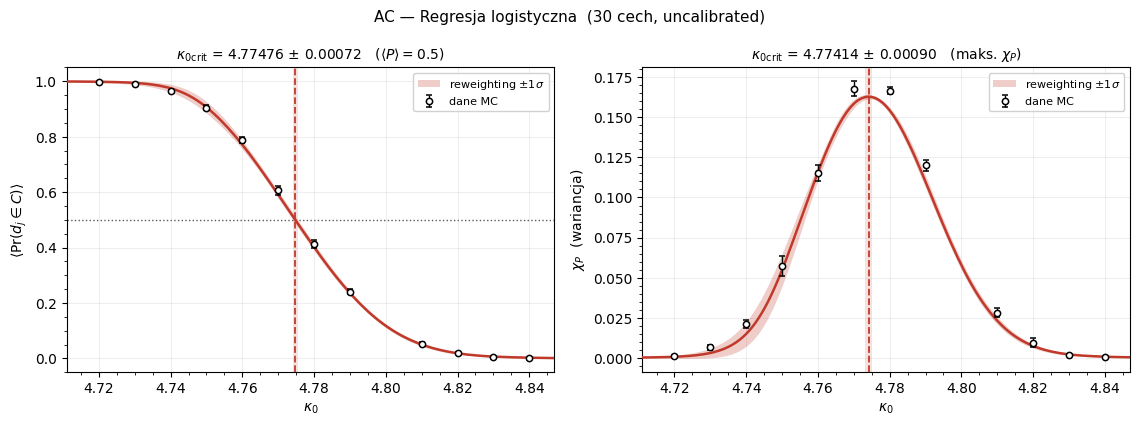

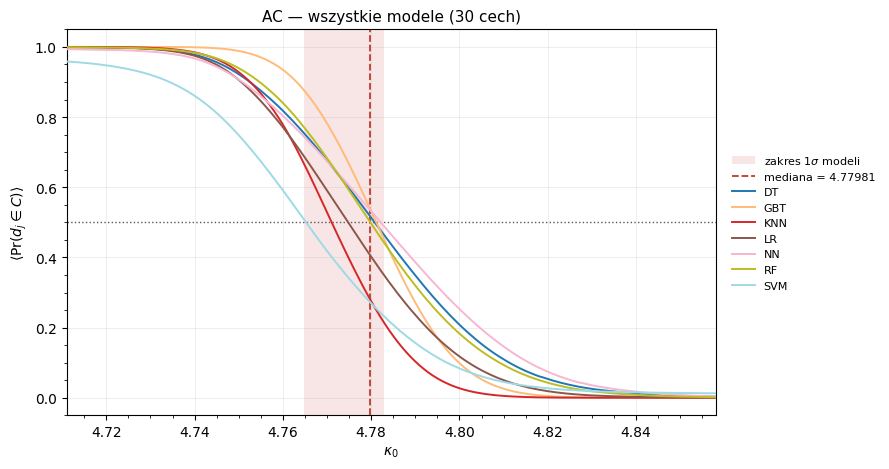

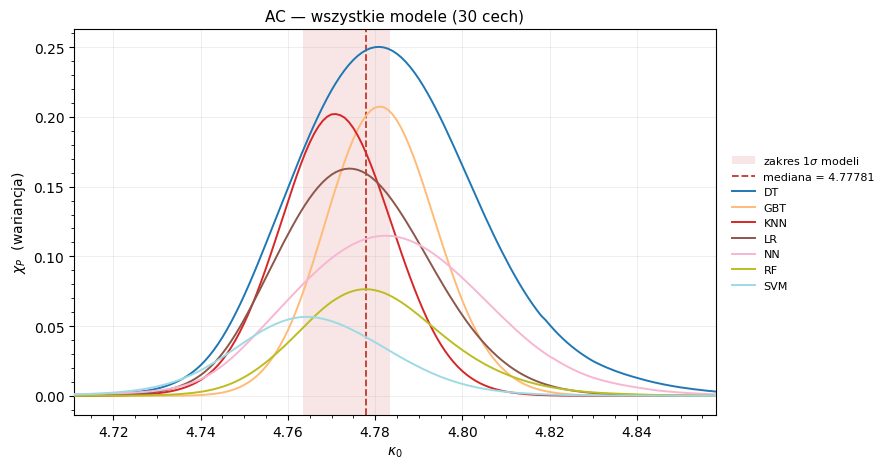

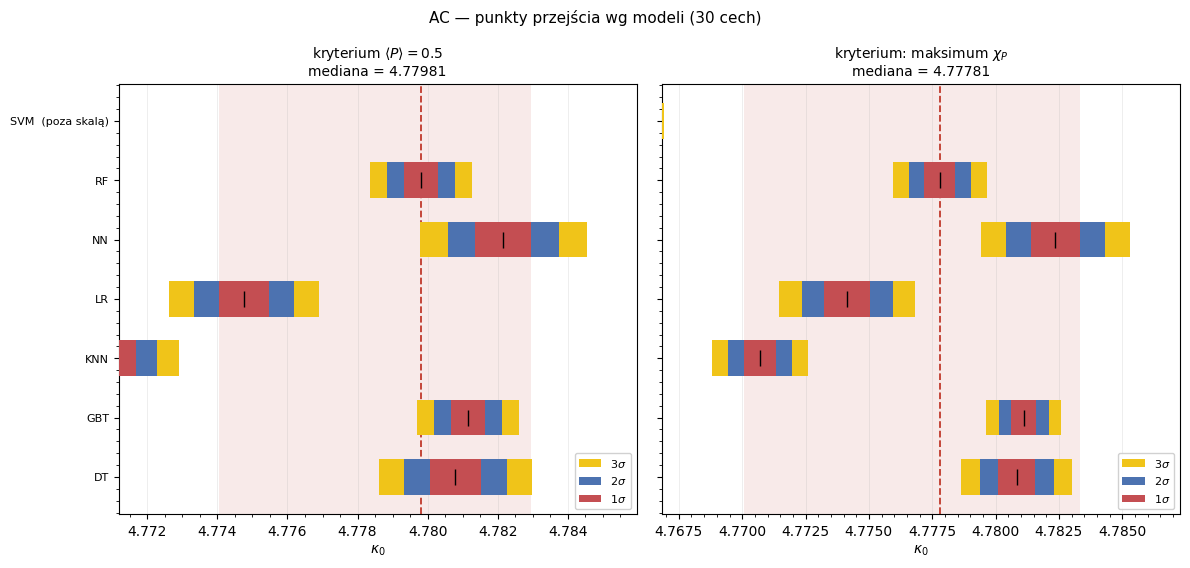

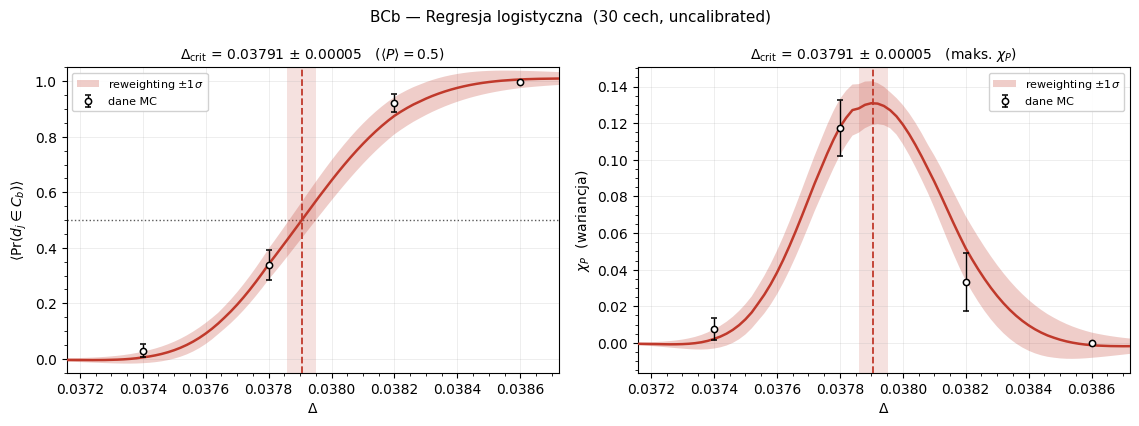

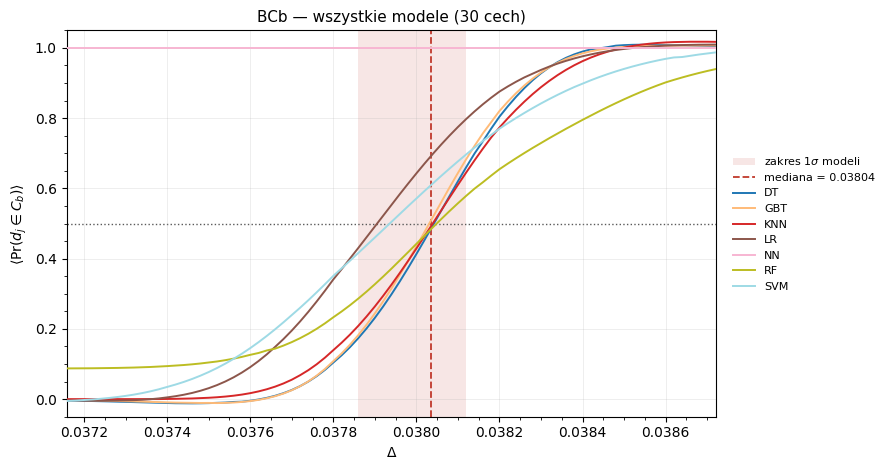

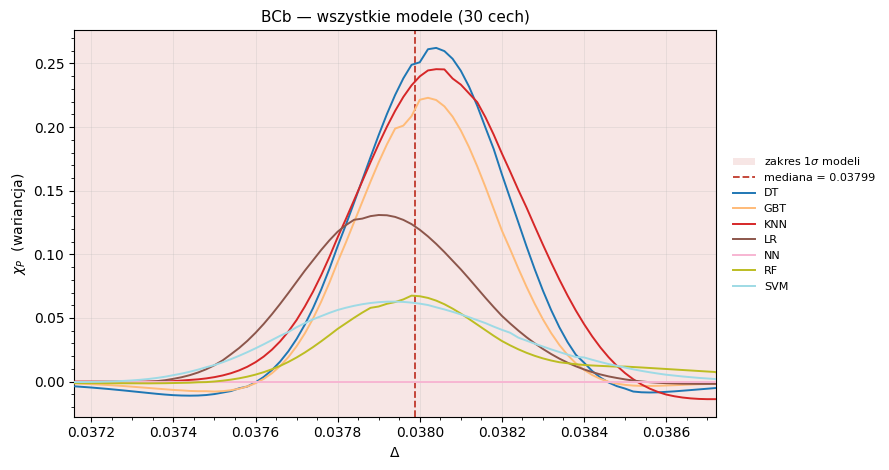

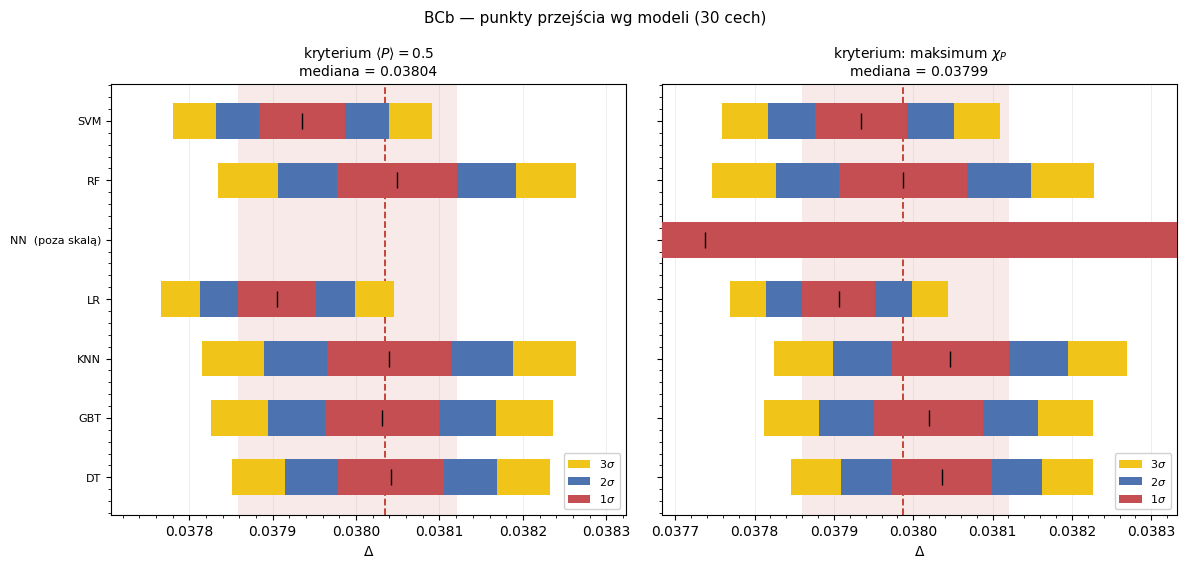

In [15]:
C_RW, C_MC, C_BAND = "#c0392b", "black", "#c0392b"

# --- polskie nazwy na wykresach --------------------------------------------------------
# Nazwy modeli w summary.csv są angielskie (pochodzą ze słownika `models` w pipelinie
# supervised), a w pracy występują po polsku - tłumaczymy je dopiero przy rysowaniu,
# żeby nie ruszać plików wynikowych. Skróty w kolumnie `tag` (LR, RF, GBT, ...) zostają.
PL_MODEL_NAMES = {
    "logistic regression":    "Regresja logistyczna",
    "decision tree":          "Drzewo decyzyjne",
    "random forest":          "Las losowy",
    "gradient boosted trees": "Wzmocnienie gradientowe",
    "knn":                    "kNN",
    "svm (rbf)":              "SVM (RBF)",
    "neural network":         "Sieć neuronowa",
}

PL_OBSERVABLES = {"variance": "wariancja", "chi": "wariancja / średnia", "mean": "średnia"}


def model_label(name: str) -> str:
    """'Neural Network' -> 'Sieć neuronowa'; nieznane nazwy zostają bez zmian."""
    n = _norm(name)
    if n in PL_MODEL_NAMES:
        return PL_MODEL_NAMES[n]
    for key, pl in sorted(PL_MODEL_NAMES.items(), key=lambda kv: -len(kv[0])):
        if n.startswith(key):
            rest = str(name).strip()[len(key):].strip()
            return f"{pl} {rest}".strip()
    return str(name)


def obs_label(col: str) -> str:
    """'variance' -> 'wariancja'."""
    return PL_OBSERVABLES.get(str(col), str(col))
PARAM_LABELS = {"K0": r"$\kappa_0$", "Delta": r"$\Delta$", "delta": r"$\Delta$"}


def param_label(key: str) -> str:
    return PARAM_LABELS.get(str(key), str(key))


def _save(fig, out_dir: Path, name: str):
    fig.savefig(out_dir / f"{name}.pdf", dpi=250, bbox_inches="tight")
    if SAVE_PDF:
        fig.savefig(out_dir / f"{name}.pdf", bbox_inches="tight")


# --- punkty MC z pipeline'u supervised -------------------------------------------------
# load_mc_points -> zdefiniowane w sekcji 9a (musi być znane przed run_transition)


# --- okno zoomu ------------------------------------------------------------------------
def transition_window(mean_df: pd.DataFrame, crit: float, pad: float = None):
    pad = ZOOM_PAD if pad is None else pad
    p, m = mean_df["param"].to_numpy(), mean_df["mean"].to_numpy()
    inside = (m > 0.02) & (m < 0.98)
    lo, hi = (p[inside].min(), p[inside].max()) if inside.sum() >= 2 else (p.min(), p.max())
    if np.isfinite(crit):
        lo, hi = min(lo, crit), max(hi, crit)
    w = max(hi - lo, 1e-12)
    return (max(lo - pad * w, p.min()), min(hi + pad * w, p.max()))   # nie wychodzimy poza siatkę


def prob_label(folder: str) -> str:
    """Etykieta osi Y dla wartości średniej prawdopodobieństwa."""
    phase = PHASE_LABEL.get(folder)
    if phase is None:
        return r"$\langle P \rangle$"
    return rf"$\langle \Pr(d_j \in {phase})\rangle$"


def _read_results(folder: str):
    """Wyniki reweightingu; kolumna "mean" odwrócona, jeśli PLOT_FLIP[folder]."""
    out_dir = RW_DIR / folder
    summary = pd.read_csv(out_dir / "summary.csv")
    mean_all = pd.read_csv(out_dir / "curve_mean.csv")
    chi_all = pd.read_csv(out_dir / "curve_chi.csv")

    if PLOT_FLIP.get(folder, False):
        mean_all = mean_all.copy()
        mean_all["mean"] = 1.0 - mean_all["mean"]     # patrz PLOT_FLIP w sekcji 1
        # "variance" i słupki błędu są niezmiennicze, kolumna "chi" = Var/mean już nie
        # (pik liczymy z "variance", więc bez wpływu na wynik)

    return summary, mean_all, chi_all, out_dir


# --- Fig. 2 / 3: zbliżenie na przejście ------------------------------------------------
def plot_transition_zoom(folder: str, tag: str = None, window=None, save=True):
    cfg = TRANSITIONS[folder]
    summary, mean_all, chi_all, out_dir = _read_results(folder)

    if tag is None:
        tag = PLOT_MODEL_TAG.get(folder, "LR")
        if tag not in set(summary["tag"]):
            tag = summary["tag"].iloc[0]
    row = summary[summary["tag"] == tag].iloc[0]

    mean_df = mean_all[mean_all["tag"] == tag].sort_values("param")
    chi_df = chi_all[chi_all["tag"] == tag].sort_values("param")
    label = param_label(row["param_key"])
    chi_col = row.get("chi_definition", CHI_FOR_PEAK)

    crit, crit_err = float(row["param_crit"]), float(row["param_crit_err"])
    peak, peak_err = float(row["chi_peak_param"]), float(row["chi_peak_err"])
    if window is None:
        window = transition_window(mean_df, crit)

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

    # --- panel 1: <P> ---
    ax = axes[0]
    p, m, e = (mean_df[c].to_numpy() for c in ("param", "mean", "mean_err"))
    ax.fill_between(p, m - e, m + e, color=C_BAND, alpha=0.25, lw=0, zorder=2,
                    label=r"reweighting $\pm 1\sigma$")
    ax.plot(p, m, color=C_RW, lw=1.8, zorder=3)

    mc = load_mc_points(folder, row["model"], "mean")
    if mc is not None:
        ax.errorbar(mc["param"], mc["value"], yerr=mc["err"], fmt="o", ms=4.5,
                    color=C_MC, mfc="white", mew=1.1, lw=1, capsize=2.5, zorder=4,
                    label="dane MC")

    ax.axhline(0.5, color="0.35", ls=":", lw=1, zorder=1)
    if np.isfinite(crit_err):
        ax.axvspan(crit - crit_err, crit + crit_err, color=C_RW, alpha=0.15, lw=0, zorder=1)
    ax.axvline(crit, color=C_RW, ls="--", lw=1.3, zorder=3)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(prob_label(folder))
    ax.set_title(f"{label}$_{{\\rm crit}}$ = {crit:.5f} $\\pm$ {crit_err:.5f}   "
                 r"($\langle P \rangle = 0.5$)", fontsize=10)

    # --- panel 2: podatność ---
    ax2 = axes[1]
    pc, c, ce = (chi_df[col].to_numpy() for col in ("param", chi_col, f"{chi_col}_err"))
    ax2.fill_between(pc, c - ce, c + ce, color=C_BAND, alpha=0.25, lw=0, zorder=2,
                     label=r"reweighting $\pm 1\sigma$")
    ax2.plot(pc, c, color=C_RW, lw=1.8, zorder=3)

    mc_chi = load_mc_points(folder, row["model"], "chi")
    if mc_chi is not None:
        ax2.errorbar(mc_chi["param"], mc_chi["value"], yerr=mc_chi["err"], fmt="o", ms=4.5,
                     color=C_MC, mfc="white", mew=1.1, lw=1, capsize=2.5, zorder=4,
                     label="dane MC")

    if np.isfinite(peak_err):
        ax2.axvspan(peak - peak_err, peak + peak_err, color=C_RW, alpha=0.15, lw=0, zorder=1)
    ax2.axvline(peak, color=C_RW, ls="--", lw=1.3, zorder=3)
    ax2.set_ylabel(rf"$\chi_P$  ({obs_label(chi_col)})")
    ax2.set_title(f"{label}$_{{\\rm crit}}$ = {peak:.5f} $\\pm$ {peak_err:.5f}   "
                  r"(maks. $\chi_P$)", fontsize=10)

    for a in axes:
        a.set_xlim(*window)
        a.set_xlabel(label)
        a.grid(alpha=0.25, lw=0.6)
        a.minorticks_on()
        a.legend(fontsize=8, framealpha=0.9)

    fig.suptitle(f"{cfg['tag']} — {model_label(row['model'])}  "
             f"({N_FEATURES} cech, {row['calibration']})",
                 fontsize=11)
    fig.tight_layout()
    if save:
        _save(fig, out_dir, f"zoom_{cfg['tag']}_{tag}")
    plt.show()


# --- Fig. 5: wszystkie modele -----------------------------------------------------------
def plot_models_overlay(folder: str, observable="mean", window=None, save=True):
    cfg = TRANSITIONS[folder]
    summary, mean_all, chi_all, out_dir = _read_results(folder)
    label = param_label(summary["param_key"].iloc[0])

    if observable == "mean":
        data, col, crit_col, err_col = mean_all, "mean", "param_crit", "param_crit_err"
        ylab = prob_label(folder)
    else:
        col = summary.get("chi_definition", pd.Series([CHI_FOR_PEAK])).iloc[0]
        data, crit_col, err_col = chi_all, "chi_peak_param", "chi_peak_err"
        ylab = rf"$\chi_P$  ({obs_label(col)})"

    crits = summary[crit_col].to_numpy(float)
    errs = summary[err_col].to_numpy(float)
    median = float(np.nanmedian(crits))
    lo_band = float(np.nanmin(crits - errs))
    hi_band = float(np.nanmax(crits + errs))

    if window is None:                      # okno = mediana okien poszczególnych modeli
        wins = np.array([transition_window(g.sort_values("param"), median)
                         for _, g in mean_all.groupby("tag")])
        window = (float(np.median(wins[:, 0])), float(np.median(wins[:, 1])))

    tags = sorted(data["tag"].unique())
    colors = dict(zip(tags, plt.cm.tab20(np.linspace(0, 1, max(len(tags), 2)))))
    fig, ax = plt.subplots(figsize=(9.0, 4.8))
    ax.axvspan(lo_band, hi_band, color=C_RW, alpha=0.12, lw=0, zorder=1,
               label=r"zakres $1\sigma$ modeli")
    ax.axvline(median, color=C_RW, ls="--", lw=1.3, zorder=2,
               label=f"mediana = {median:.5f}")

    for tag in tags:
        g = data[data["tag"] == tag].sort_values("param")
        ax.plot(g["param"], g[col], lw=1.4, color=colors[tag], zorder=3, label=tag)

    if observable == "mean":
        ax.axhline(0.5, color="0.35", ls=":", lw=1, zorder=1)
        ax.set_ylim(-0.05, 1.05)

    ax.set_xlim(*window)
    ax.set_xlabel(label)
    ax.set_ylabel(ylab)
    ax.grid(alpha=0.25, lw=0.6)
    ax.minorticks_on()
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    ax.set_title(f"{cfg['tag']} — wszystkie modele ({N_FEATURES} cech)", fontsize=11)
    fig.tight_layout()
    if save:
        _save(fig, out_dir, f"overlay_{cfg['tag']}_{observable}")
    plt.show()


# --- Fig. 6: zestawienie punktów krytycznych -------------------------------------------
SIGMA_COLORS = [(3, "#f0c419", r"$3\sigma$"), (2, "#4c72b0", r"$2\sigma$"), (1, "#c44e52", r"$1\sigma$")]


def plot_crit_summary(folder: str, save=True):
    cfg = TRANSITIONS[folder]
    summary, _, _, out_dir = _read_results(folder)
    label = param_label(summary["param_key"].iloc[0])

    panels = [("param_crit", "param_crit_err", r"kryterium $\langle P \rangle = 0.5$"),
              ("chi_peak_param", "chi_peak_err", r"kryterium: maksimum $\chi_P$")]

    fig, axes = plt.subplots(1, 2, figsize=(12, 0.45 * len(summary) + 2.6), sharey=True)

    for ax, (c_val, c_err, title) in zip(axes, panels):
        s = summary.sort_values("tag").reset_index(drop=True)
        vals, errs = s[c_val].to_numpy(float), s[c_err].to_numpy(float)
        median = float(np.nanmedian(vals))

        # modele odstające (ogromny błąd / daleko od mediany) nie rozciągają osi ani pasma
        finite = np.isfinite(vals) & np.isfinite(errs)
        scale = float(np.nanmedian(errs[finite])) if finite.any() else 0.0
        if not np.isfinite(scale) or scale <= 0:
            scale = float(np.nanstd(vals[finite])) if finite.any() else 1.0
        keep = finite & (np.abs(vals - median) <= 10 * scale) & (errs <= 10 * scale)
        if keep.sum() < 2:
            keep = finite

        lo, hi = float(np.min((vals - errs)[keep])), float(np.max((vals + errs)[keep]))
        x_lo, x_hi = float(np.min((vals - 3 * errs)[keep])), float(np.max((vals + 3 * errs)[keep]))
        pad = 0.12 * max(x_hi - x_lo, 1e-12)

        ax.axvspan(lo, hi, color=C_RW, alpha=0.10, lw=0, zorder=1)
        ax.axvline(median, color=C_RW, ls="--", lw=1.3, zorder=2)

        for i, (v, e) in enumerate(zip(vals, errs)):
            if not np.isfinite(v):
                continue
            e = 0.0 if not np.isfinite(e) else e
            for k, (mult, color, _lbl) in enumerate(SIGMA_COLORS):
                ax.barh(i, 2 * mult * e, left=v - mult * e, height=0.6,
                        color=color, zorder=3 + k,
                        label=_lbl if i == 0 else None)
            ax.plot([v], [i], marker="|", ms=12, color="black", zorder=10)

        ax.set_xlim(x_lo - pad, x_hi + pad)
        ax.set_yticks(range(len(s)))
        labels = [t if k else f"{t}  (poza skalą)" for t, k in zip(s["tag"], keep)]
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel(label)
        ax.set_title(f"{title}\nmediana = {median:.5f}", fontsize=10)
        ax.grid(axis="x", alpha=0.25, lw=0.6)
        ax.minorticks_on()
        ax.legend(fontsize=8, loc="lower right", framealpha=0.9)

    fig.suptitle(f"{cfg['tag']} — punkty przejścia wg modeli ({N_FEATURES} cech)", fontsize=11)
    fig.tight_layout()
    if save:
        _save(fig, out_dir, f"crit_summary_{cfg['tag']}")
    plt.show()


if MAKE_PLOTS:
    for folder in TRANSITIONS_TO_RUN:
        if not (RW_DIR / folder / "summary.csv").exists():
            print(f"[{folder}] brak wyników")
            continue
        plot_transition_zoom(folder)
        plot_models_overlay(folder, "mean")
        plot_models_overlay(folder, "chi")
        plot_crit_summary(folder)


### Całe przejście i osobno przecięcie z `0.5`

Dwie funkcje, każda daje osobny rysunek, oba z wszystkimi modelami (każdy w innym kolorze)
i z pasmami `1σ`:

* `plot_transition_all(folder)` — **pełny zakres** parametru: krzywe `<P>` z pasmami `1σ`,
  linia `0.5`, szare pionowe linie w punktach `param_close` (skąd robiony jest reweighting)
  oraz zacieniowany obszar, gdzie `ESS/N < ESS_MIN_FRAC` (tam reweighting nie jest wiarygodny).
* `plot_crossing_all(folder)` — **zoom na `<P> = 0.5`**: to samo w oknie `± CROSS_SIGMA·σ` wokół
  punktów krytycznych, a pod spodem panel z `κ₀^crit ± 1σ` dla każdego modelu (te same kolory).

Dla podatności wystarczy `observable="variance"` (albo `"chi"`) — wtedy kryterium jest pik,
a okno zoomu liczone jest wokół `chi_peak_param`.


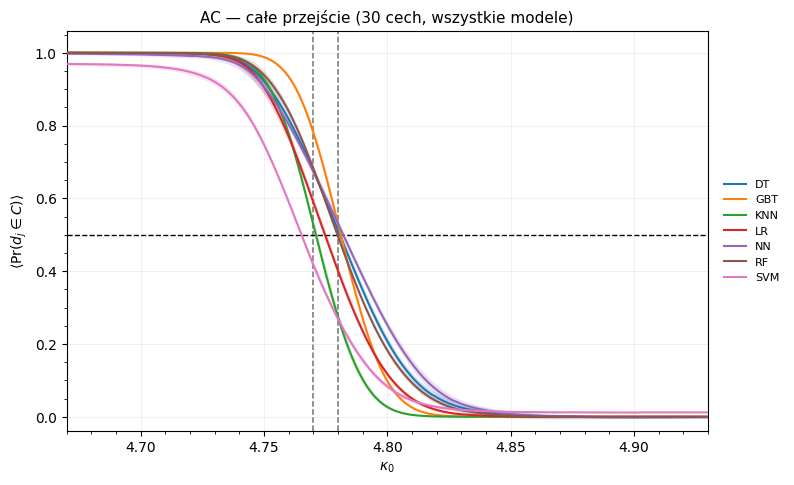

[c_a] poza oknem zoomu (odstające): ['KNN', 'SVM']


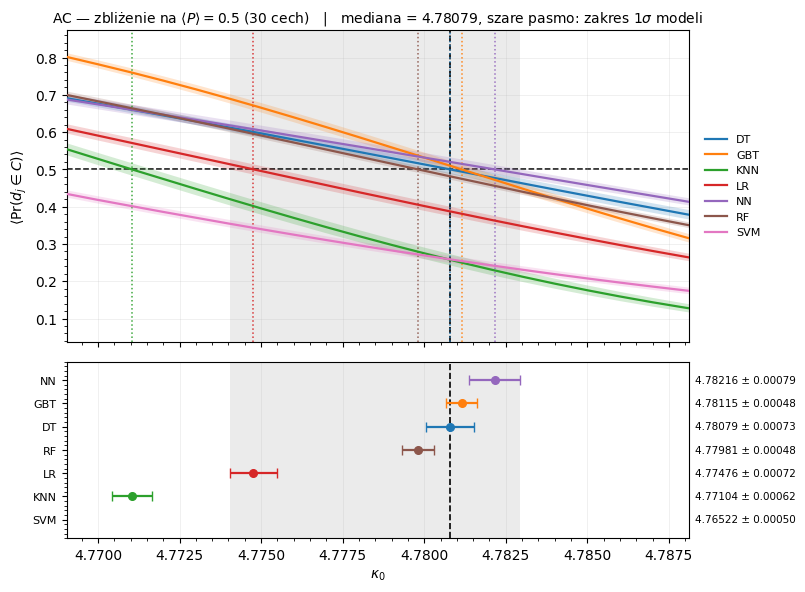

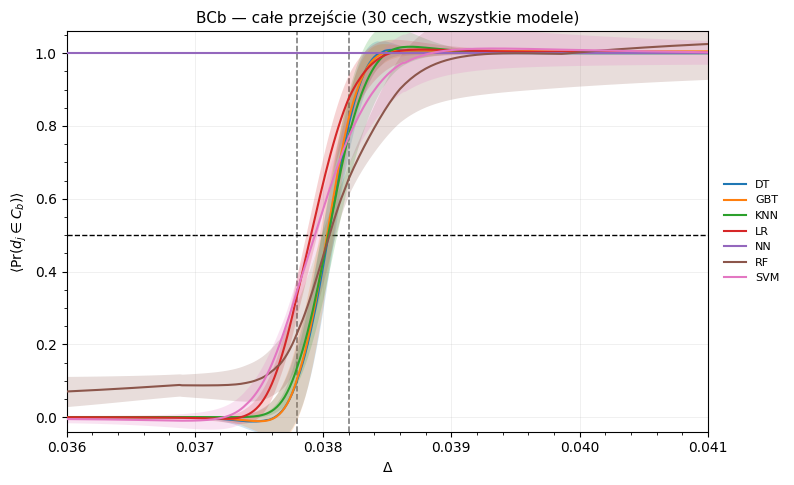

[b_cb] bez wyznaczonego punktu krytycznego: ['NN']


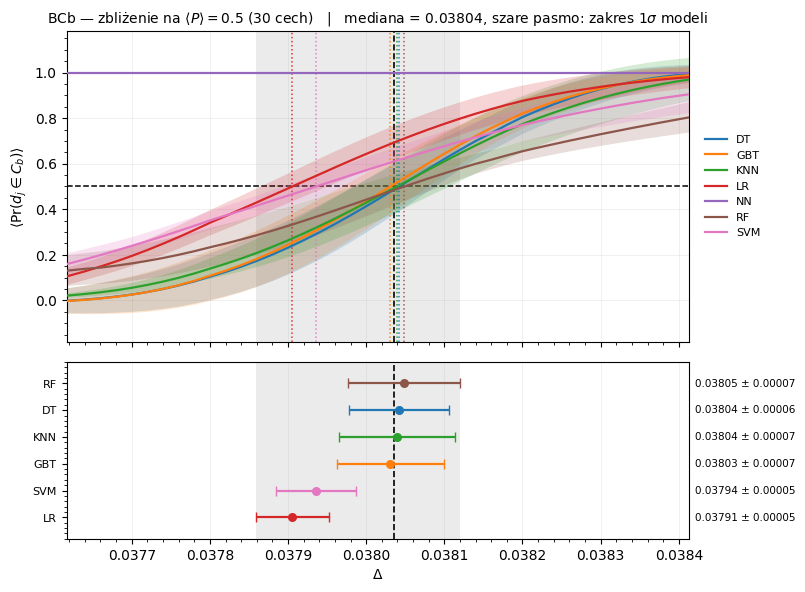

In [16]:

def model_colors(tags):
    """Stały kolor na model - ten sam na obu rysunkach."""
    tags = sorted(tags)
    palette = list(plt.cm.tab10.colors) + list(plt.cm.tab20b.colors)
    return {t: palette[i % len(palette)] for i, t in enumerate(tags)}


def robust_keep(crits, errs, factor=10.0):
    """Maska modeli, które nie są odstające - do skalowania osi i pasma 1 sigma."""
    crits, errs = np.asarray(crits, float), np.asarray(errs, float)
    finite = np.isfinite(crits) & np.isfinite(errs)
    if finite.sum() <= 2:
        return finite
    median = float(np.median(crits[finite]))
    scale = float(np.median(errs[finite]))
    if not np.isfinite(scale) or scale <= 0:
        scale = float(np.std(crits[finite])) or 1.0
    keep = finite & (np.abs(crits - median) <= factor * scale) & (errs <= factor * scale)
    return keep if keep.sum() >= 2 else finite


def _obs_cols(observable: str):
    if observable == "mean":
        return "mean", "mean_err", "param_crit", "param_crit_err", r"$\langle \Pr(d_j \in C)\rangle$"
    col = CHI_FOR_PEAK if observable == "auto" else observable
    return col, f"{col}_err", "chi_peak_param", "chi_peak_err", rf"$\chi_P$  ({obs_label(col)})"


def _model_table(folder, observable, tags=None):
    summary, mean_all, chi_all, out_dir = _read_results(folder)
    col, err_col, crit_col, crit_err_col, ylab = _obs_cols(observable)
    if observable == "mean":
        ylab = prob_label(folder)
    data = mean_all if observable == "mean" else chi_all
    if tags is not None:
        summary = summary[summary["tag"].isin(tags)]
        data = data[data["tag"].isin(tags)]
    return summary, data, out_dir, col, err_col, crit_col, crit_err_col, ylab


# =======================================================================================
# 1) CAŁE PRZEJŚCIE
# =======================================================================================
def plot_transition_all(folder: str, observable="mean", tags=None, window=None,
                        band=True, save=True):
    cfg = TRANSITIONS[folder]
    summary, data, out_dir, col, err_col, crit_col, _, ylab = _model_table(folder, observable, tags)
    label = param_label(summary["param_key"].iloc[0])
    colors = model_colors(data["tag"].unique())

    fig, ax = plt.subplots(figsize=(9.5, 5.2))

    # obszar, gdzie reweighting przestaje być wiarygodny
    if SHOW_ESS_SHADE:
        ess = data.groupby("param")["ess_frac"].max().sort_index()
        ax.fill_between(ess.index.to_numpy(), 0, 1, where=(ess.to_numpy() < ESS_MIN_FRAC),
                        transform=ax.get_xaxis_transform(), color="0.85", alpha=0.55,
                        lw=0, zorder=0, label=f"ESS/N < {ESS_MIN_FRAC}")

    # punkty MC, z których robimy reweighting
    for pc in sorted(summary["param_close"].unique()):
        ax.axvline(pc, color="0.45", ls="--", lw=1.1, zorder=1)

    for tag in sorted(data["tag"].unique()):
        g = data[data["tag"] == tag].sort_values("param")
        x, y, e = (g[c].to_numpy(float) for c in ("param", col, err_col))
        if band:
            ax.fill_between(x, y - e, y + e, color=colors[tag], alpha=0.20, lw=0, zorder=2)
        ax.plot(x, y, color=colors[tag], lw=1.5, zorder=3, label=tag)

    if observable == "mean":
        ax.axhline(0.5, color="black", ls="--", lw=1, zorder=1)
        ax.set_ylim(-0.04, 1.06)

    ax.set_xlim(*(window if window else (data["param"].min(), data["param"].max())))
    ax.set_xlabel(label)
    ax.set_ylabel(ylab)
    ax.grid(alpha=0.22, lw=0.6)
    ax.minorticks_on()
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    ax.set_title(f"{cfg['tag']} — całe przejście ({N_FEATURES} cech, wszystkie modele)", fontsize=11)

    fig.subplots_adjust(right=0.80)
    if save:
        _save(fig, out_dir, f"full_{cfg['tag']}_{observable}")
    plt.show()


# =======================================================================================
# 2) ZOOM NA <P> = 0.5  (albo na pik podatności)
# =======================================================================================
def plot_crossing_all(folder: str, observable="mean", tags=None, sigma=None, pad=None,
                      window=None, save=True):
    cfg = TRANSITIONS[folder]
    summary, data, out_dir, col, err_col, crit_col, crit_err_col, ylab = _model_table(
        folder, observable, tags)
    label = param_label(summary["param_key"].iloc[0])
    colors = model_colors(data["tag"].unique())

    sigma = CROSS_SIGMA if sigma is None else sigma
    pad = CROSS_PAD if pad is None else pad

    s = summary[["tag", "model", crit_col, crit_err_col]].copy()
    s.columns = ["tag", "model", "crit", "err"]
    s["err"] = s["err"].fillna(0.0)
    ok = s[np.isfinite(s["crit"])].sort_values("crit").reset_index(drop=True)
    missing = sorted(set(s["tag"]) - set(ok["tag"]))
    if missing:
        print(f"[{folder}] bez wyznaczonego punktu krytycznego: {missing}")
    if ok.empty:
        print(f"[{folder}] brak modeli z punktem krytycznym - pomijam")
        return

    # okno = zakres punktów krytycznych +- sigma*1s (bez modeli odstających), z marginesem
    keep = robust_keep(ok["crit"], ok["err"])
    base = ok[keep]
    outliers = sorted(ok.loc[~keep, "tag"])
    if outliers:
        print(f"[{folder}] poza oknem zoomu (odstające): {outliers}")
    lo = float((base["crit"] - sigma * base["err"]).min())
    hi = float((base["crit"] + sigma * base["err"]).max())
    step = float(np.median(np.diff(np.unique(data["param"].to_numpy()))))
    if hi - lo < 4 * step:
        mid = 0.5 * (lo + hi)
        lo, hi = mid - 2 * step, mid + 2 * step
    w = hi - lo
    if window is None:
        window = (max(lo - pad * w, data["param"].min()), min(hi + pad * w, data["param"].max()))

    median = float(np.median(base["crit"]))
    band_lo = float((base["crit"] - base["err"]).min())
    band_hi = float((base["crit"] + base["err"]).max())

    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(9.5, 6.6), sharex=True,
                                  gridspec_kw=dict(height_ratios=[3, 1.7], hspace=0.08))

    # --- panel górny: krzywe z pasmami 1 sigma ---
    for tag in sorted(data["tag"].unique()):
        g = data[data["tag"] == tag].sort_values("param")
        x, y, e = (g[c].to_numpy(float) for c in ("param", col, err_col))
        ax.fill_between(x, y - e, y + e, color=colors[tag], alpha=0.20, lw=0, zorder=2)
        ax.plot(x, y, color=colors[tag], lw=1.6, zorder=3, label=tag)

    for _, r in ok.iterrows():
        ax.axvline(r["crit"], color=colors[r["tag"]], ls=":", lw=1.1, alpha=0.9, zorder=2)

    if observable == "mean":
        ax.axhline(0.5, color="black", ls="--", lw=1.1, zorder=1)

    sel = data[(data["param"] >= window[0]) & (data["param"] <= window[1])]
    if not sel.empty:
        y_lo = float((sel[col] - sel[err_col]).min())
        y_hi = float((sel[col] + sel[err_col]).max())
        m = 0.12 * max(y_hi - y_lo, 1e-12)
        if observable == "mean":
            y_lo, y_hi = max(y_lo, -0.05), min(y_hi, 1.05)
        ax.set_ylim(y_lo - m, y_hi + m)

    ax.set_ylabel(ylab)
    ax.grid(alpha=0.22, lw=0.6)
    ax.minorticks_on()
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    crit_name = (r"$\langle P \rangle = 0.5$" if observable == "mean"
                 else r"maksimum $\chi_P$")
    ax.set_title(f"{cfg['tag']} — zbliżenie na {crit_name} ({N_FEATURES} cech)   |   "
                 + f"mediana = {median:.5f}, " + r"szare pasmo: zakres $1\sigma$ modeli",
                 fontsize=10)

    # --- panel dolny: punkt krytyczny +- 1 sigma dla każdego modelu ---
    for a in (ax, ax2):
        a.axvspan(band_lo, band_hi, color="0.75", alpha=0.30, lw=0, zorder=0)
        a.axvline(median, color="black", ls="--", lw=1.2, zorder=1)

    for i, r in ok.iterrows():
        ax2.errorbar(r["crit"], i, xerr=r["err"], fmt="o", ms=5.5, color=colors[r["tag"]],
                     ecolor=colors[r["tag"]], elinewidth=1.6, capsize=3.5, zorder=3)
        ax2.annotate(f"{r['crit']:.5f} ± {r['err']:.5f}", xy=(1.01, i),
                     xycoords=("axes fraction", "data"), fontsize=7.5, va="center")

    ax2.set_yticks(range(len(ok)))
    ax2.set_yticklabels(ok["tag"], fontsize=8)
    ax2.set_ylim(-0.8, len(ok) - 0.2)
    ax2.set_xlim(*window)
    ax2.set_xlabel(label)
    ax2.grid(axis="x", alpha=0.22, lw=0.6)
    ax2.minorticks_on()

    fig.subplots_adjust(right=0.78, hspace=0.08)
    if save:
        _save(fig, out_dir, f"crossing_{cfg['tag']}_{observable}")
    plt.show()


if MAKE_PLOTS:
    for folder in TRANSITIONS_TO_RUN:
        if (RW_DIR / folder / "summary.csv").exists():
            plot_transition_all(folder, "mean")
            plot_crossing_all(folder, "mean")


## 13. Diagnostyka: SE w funkcji `B` (kontrola plateau)

`BLOCK_SELECTION="max_se"` bierze najbardziej konserwatywny błąd, ale fizycznie poprawny jest
błąd z **plateau**. Ta komórka rysuje `SE(B)` dla wybranego modelu w kilku punktach siatki —
jeśli plateau jest wyraźne, warto przełączyć się na `BLOCK_SELECTION="fixed"` z `FIXED_BLOCK_COUNT`
odczytanym z wykresu.

   FULL : X=(1501444, 30), 'K0' -> 20 wartości
   TRAIN: X=(74445, 30), klasy=[0 1]


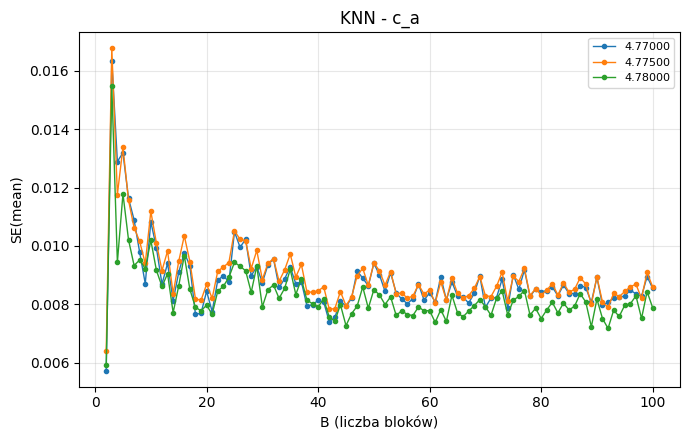

In [17]:
def plot_se_vs_B(folder: str, tag: str, params=None, observable="mean"):
    cfg = TRANSITIONS[folder]
    kind = cfg["kind"]

    k4_table = build_k4_table(transition_paths(folder)["raw"], kind)
    fk4 = build_fk4(k4_table)
    data = load_transition_data(folder, kind)

    index = pd.read_csv(RW_DIR / folder / "probabilities_index.csv")
    row = index[index["tag"] == tag].iloc[0]

    mask, param_close = select_configs(data["param_full"], float(row["param_close"]))
    d = np.asarray(data["X_full"][mask], dtype=np.float64)
    P = np.loadtxt(PROB_DIR / row["prob_file"])
    if resolve_flip(folder, row["model"], P, d, param_close, fk4, kind, verbose=False):
        P = 1.0 - P

    n0, n4, n41 = d[:, IDX_N0], d[:, IDX_N4], d[:, IDX_N41]
    center = np.median if CENTER == "median" else np.mean
    meds = (float(center(n0)), float(center(n4)), float(center(n41)))
    k4_ref = float(fk4(param_close))

    if params is None:
        step = cfg.get("grid_step") or 0.001
        params = [param_close, param_close + 5 * step, param_close + 10 * step]

    plt.figure(figsize=(7, 4.5))
    for p in params:
        w = reweighting_weights(n0, n4, n41, param=float(p), param_ref=param_close,
                                k4=float(fk4(p)), k4_ref=k4_ref, kind=kind, meds=meds)
        wp = w * P
        Bs, ses = [], []
        for B in BLOCK_COUNTS:
            res = block_jackknife_sums(w, wp, wp * P, B)
            if res is None:
                continue
            Bs.append(B)
            ses.append(res[observable]["se"])
        plt.plot(Bs, ses, marker="o", ms=3, lw=1, label=f"{p:.5f}")

    plt.xlabel("B (liczba bloków)")
    plt.ylabel(f"SE({observable})")
    plt.title(f"{tag} - {folder}")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# przykład:
plot_se_vs_B("c_a", "KNN")


## 15. Wykresy „z pazurem"

Trzy rysunki, które da się policzyć z tego, co już jest na dysku:

1. **`plot_ml_vs_op`** — ML kontra klasyczny parametr porządku na jednym rysunku.
   `OP1 = N0/N41` i `OP2 = N4/N41 - 1` liczymy **z tych samych 30 cech**, reweightujemy tą samą
   procedurą i porównujemy szerokości `1σ`. To jest ten wynik z pracy („ML jest 3× dokładniejszy"),
   tylko na Twoich danych i z Twoimi modelami.
2. **`plot_reweighted_histograms`** — histogramy `P(d_j)` i `OP2` przereważone do kilku wartości
   parametru, z **jednego** przebiegu MC. Widać, dlaczego reweighting działa dla `P` (rozkład siedzi
   w [0, 1] i histogramy się nakładają), a dla `OP2` nie (nośniki uciekają).
3. **`plot_criteria_agreement`** — zgodność dwóch kryteriów (`<P> = 0.5` vs pik `χ`) model po modelu,
   z błędami w obu osiach.

Mapowanie kolumn cech jest tu weryfikowane tożsamościami z pracy: `N1 = 3*N0 + N4/2`
oraz `N2 = 2*N0 + 2*N4` — jeśli się zgadzają, to `N0, N4, N41` siedzą tam, gdzie zakładamy.


   FULL : X=(1501444, 30), 'K0' -> 20 wartości
   TRAIN: X=(74445, 30), klasy=[0 1]
   tożsamości cech: N1 = 3*N0 + N4/2 -> OK, N2 = 2*N0 + 2*N4 -> OK
   reweighting OP2 (261 punktów siatki)...


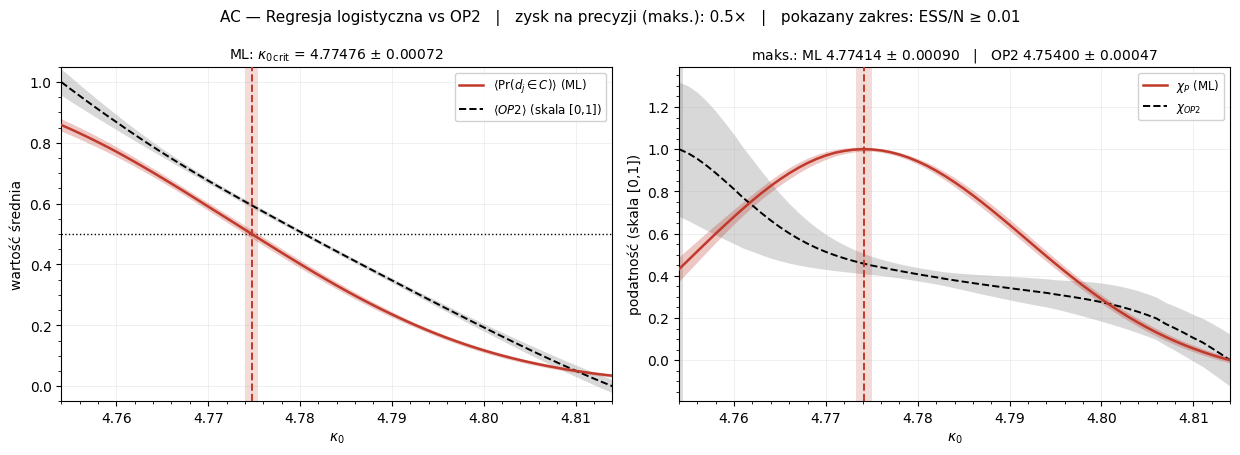

   FULL : X=(1501444, 30), 'K0' -> 20 wartości
   TRAIN: X=(74445, 30), klasy=[0 1]


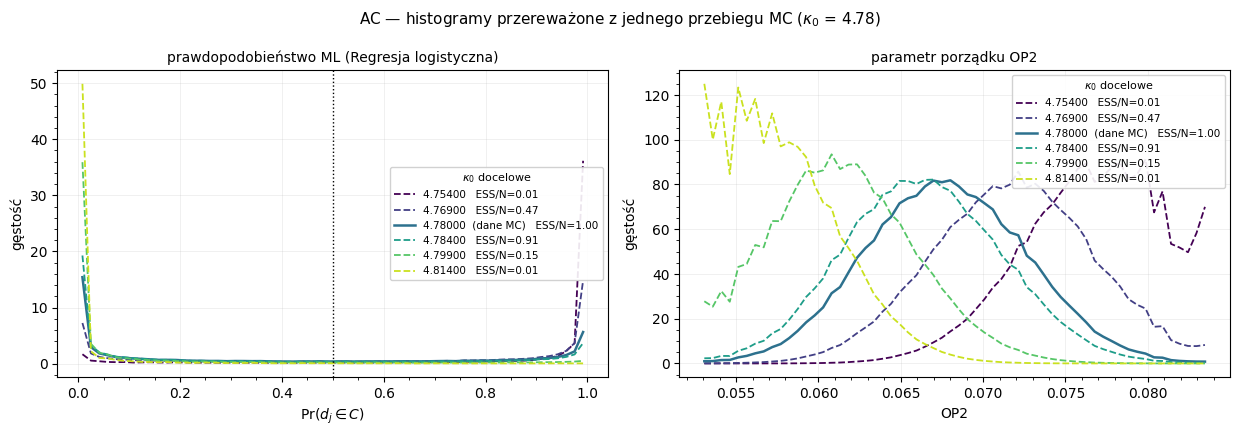

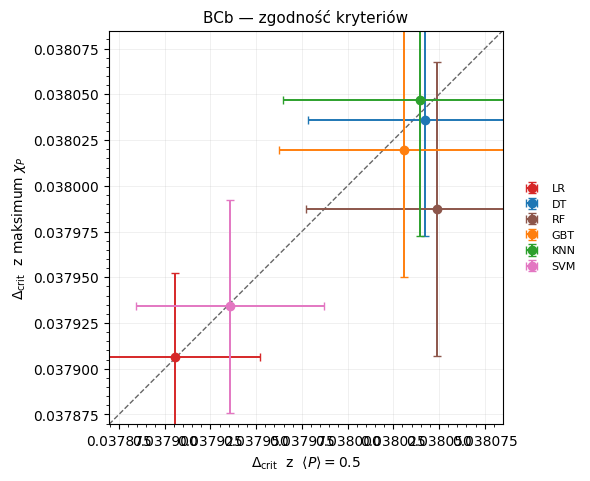

In [18]:

def load_model_sample(folder: str, tag: str):
    """Zwraca (P, d, param_close, fk4, k4_table, kind, row) dla jednego modelu."""
    cfg = TRANSITIONS[folder]
    kind = cfg["kind"]
    k4_table = build_k4_table(transition_paths(folder)["raw"], kind)
    fk4 = build_fk4(k4_table)
    data = load_transition_data(folder, kind)

    index = pd.read_csv(RW_DIR / folder / "probabilities_index.csv")
    row = index[index["tag"] == tag].iloc[0]

    mask, param_close = select_configs(data["param_full"], float(row["param_close"]))
    d = np.asarray(data["X_full"][mask], dtype=np.float64)
    P = np.loadtxt(PROB_DIR / row["prob_file"])
    if resolve_flip(folder, row["model"], P, d, param_close, fk4, kind, verbose=False):
        P = 1.0 - P
    return P, d, param_close, fk4, k4_table, kind, row


def check_feature_identities(d: np.ndarray, atol=1e-6):
    """Tożsamości z Appendix 1: N1 = 3*N0 + N4/2, N2 = 2*N0 + 2*N4 (weryfikacja indeksów cech)."""
    n0, n1, n2, n4 = d[:, 0], d[:, 1], d[:, 2], d[:, IDX_N4]
    ok1 = np.allclose(n1, 3 * n0 + n4 / 2, atol=atol)
    ok2 = np.allclose(n2, 2 * n0 + 2 * n4, atol=atol)
    print(f"   tożsamości cech: N1 = 3*N0 + N4/2 -> {'OK' if ok1 else 'NIE'}, "
          f"N2 = 2*N0 + 2*N4 -> {'OK' if ok2 else 'NIE'}")
    return ok1 and ok2


def order_parameters_from_features(d: np.ndarray) -> dict:
    """Standardowe parametry porządku CDT liczone z tych samych 30 cech."""
    n0, n4, n41 = d[:, IDX_N0], d[:, IDX_N4], d[:, IDX_N41]
    return {"OP1": n0 / n41, "OP2": n4 / n41 - 1.0}


def _rescale01(y, e=None, ref=None):
    ref = y if ref is None else ref
    lo, hi = float(np.nanmin(ref)), float(np.nanmax(ref))
    span = (hi - lo) or 1.0
    return (y - lo) / span, (None if e is None else e / span)


# =======================================================================================
# 1) ML kontra parametr porządku
# =======================================================================================
def plot_ml_vs_op(folder: str, tag: str = None, op: str = "OP2", window=None, save=True):
    cfg = TRANSITIONS[folder]
    summary, mean_all, chi_all, out_dir = _read_results(folder)
    if tag is None:
        tag = PLOT_MODEL_TAG.get(folder, "LR")
        if tag not in set(summary["tag"]):
            tag = summary["tag"].iloc[0]
    row = summary[summary["tag"] == tag].iloc[0]
    label = param_label(row["param_key"])
    chi_col = row.get("chi_definition", CHI_FOR_PEAK)

    P, d, param_close, fk4, k4_table, kind, _ = load_model_sample(folder, tag)
    check_feature_identities(d)

    op_values = order_parameters_from_features(d)[op]
    grid = make_grid(k4_table, param_close, cfg.get("grid_step"))
    print(f"   reweighting {op} ({len(grid)} punktów siatki)...")
    op_curve = reweighted_jackknife_curve(op_values, d, param_close, fk4, grid, kind)

    ess_ok = (op_curve["ess_frac"] >= ESS_MIN_FRAC).to_numpy()
    op_peak, op_peak_err, _ = jackknife_locate(op_curve, chi_col, "peak", mask=ess_ok)

    ml_mean = mean_all[mean_all["tag"] == tag].sort_values("param")
    ml_chi = chi_all[chi_all["tag"] == tag].sort_values("param")
    ml_crit, ml_crit_err = float(row["param_crit"]), float(row["param_crit_err"])
    ml_peak, ml_peak_err = float(row["chi_peak_param"]), float(row["chi_peak_err"])

    # rysujemy tylko tam, gdzie reweighting jest wiarygodny (ESS/N >= ESS_MIN_FRAC)
    valid = op_curve.loc[ess_ok, "param"]
    if window is None:
        window = transition_window(ml_mean, ml_crit, pad=0.6)
    if not valid.empty:
        window = (max(window[0], float(valid.min())), min(window[1], float(valid.max())))

    in_win = lambda df: df[(df["param"] >= window[0]) & (df["param"] <= window[1])]
    ml_mean, ml_chi, op_curve_p = in_win(ml_mean), in_win(ml_chi), in_win(op_curve)

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

    # --- panel 1: wartości średnie ---
    ax = axes[0]
    x, y, e = (ml_mean[c].to_numpy(float) for c in ("param", "mean", "mean_err"))
    ax.fill_between(x, y - e, y + e, color=C_RW, alpha=0.28, lw=0, zorder=2)
    ax.plot(x, y, color=C_RW, lw=1.8, zorder=3, label=r"$\langle \Pr(d_j \in C)\rangle$ (ML)")

    xo = op_curve_p["param"].to_numpy()
    yo, eo = _rescale01(op_curve_p["mean"].to_numpy(), op_curve_p["mean_err"].to_numpy())
    ax.fill_between(xo, yo - eo, yo + eo, color="0.4", alpha=0.25, lw=0, zorder=1)
    ax.plot(xo, yo, color="black", ls="--", lw=1.4, zorder=2, label=rf"$\langle {op}\rangle$ (skala [0,1])")

    ax.axhline(0.5, color="black", ls=":", lw=1, zorder=1)
    ax.axvspan(ml_crit - ml_crit_err, ml_crit + ml_crit_err, color=C_RW, alpha=0.18, lw=0, zorder=1)
    ax.axvline(ml_crit, color=C_RW, ls="--", lw=1.4, zorder=3)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("wartość średnia")
    ax.set_title(rf"ML: {label}$_{{\rm crit}}$ = {ml_crit:.5f} $\pm$ {ml_crit_err:.5f}", fontsize=10)

    # --- panel 2: podatności ---
    ax2 = axes[1]
    xc = ml_chi["param"].to_numpy(float)
    yc, ec = _rescale01(ml_chi[chi_col].to_numpy(float), ml_chi[f"{chi_col}_err"].to_numpy(float))
    ax2.fill_between(xc, yc - ec, yc + ec, color=C_RW, alpha=0.28, lw=0, zorder=2)
    ax2.plot(xc, yc, color=C_RW, lw=1.8, zorder=3, label=r"$\chi_P$ (ML)")

    yq, eq = _rescale01(op_curve_p[chi_col].to_numpy(), op_curve_p[f"{chi_col}_err"].to_numpy())
    ax2.fill_between(xo, yq - eq, yq + eq, color="0.4", alpha=0.25, lw=0, zorder=1)
    ax2.plot(xo, yq, color="black", ls="--", lw=1.4, zorder=2, label=rf"$\chi_{{{op}}}$")

    ax2.axvspan(ml_peak - ml_peak_err, ml_peak + ml_peak_err, color=C_RW, alpha=0.18, lw=0, zorder=1)
    ax2.axvline(ml_peak, color=C_RW, ls="--", lw=1.4, zorder=3)
    if np.isfinite(op_peak):
        ax2.axvspan(op_peak - op_peak_err, op_peak + op_peak_err, color="0.4", alpha=0.22, lw=0, zorder=1)
        ax2.axvline(op_peak, color="black", ls="--", lw=1.4, zorder=2)
    ax2.set_ylabel("podatność (skala [0,1])")
    ax2.set_title(rf"maks.: ML {ml_peak:.5f} $\pm$ {ml_peak_err:.5f}   |   "
                  rf"{op} {op_peak:.5f} $\pm$ {op_peak_err:.5f}", fontsize=10)

    gain = op_peak_err / ml_peak_err if (np.isfinite(op_peak_err) and ml_peak_err > 0) else np.nan
    for a in axes:
        a.set_xlim(*window)
        a.set_xlabel(label)
        a.grid(alpha=0.22, lw=0.6)
        a.minorticks_on()
        a.legend(fontsize=8.5, framealpha=0.9)

    fig.suptitle(f"{cfg['tag']} — {model_label(row['model'])} vs {op}   |   "
                 f"zysk na precyzji (maks.): {gain:.1f}×   |   "
                 f"pokazany zakres: ESS/N ≥ {ESS_MIN_FRAC}", fontsize=11)
    fig.tight_layout()
    if save:
        _save(fig, out_dir, f"ml_vs_{op}_{cfg['tag']}_{tag}")
    plt.show()
    return op_curve


# =======================================================================================
# 2) Histogramy przereważone - dlaczego reweighting działa dla P, a nie dla OP
# =======================================================================================
def plot_reweighted_histograms(folder: str, tag: str = None, targets=None, n_targets=5,
                               bins=60, op: str = "OP2", save=True):
    cfg = TRANSITIONS[folder]
    summary, mean_all, _, out_dir = _read_results(folder)
    if tag is None:
        tag = PLOT_MODEL_TAG.get(folder, "LR")
        if tag not in set(summary["tag"]):
            tag = summary["tag"].iloc[0]
    row = summary[summary["tag"] == tag].iloc[0]
    label = param_label(row["param_key"])

    P, d, param_close, fk4, k4_table, kind, _ = load_model_sample(folder, tag)
    if PLOT_FLIP.get(folder, False):
        P = 1.0 - P                      # patrz PLOT_FLIP w sekcji 1
    op_values = order_parameters_from_features(d)[op]

    if targets is None:                       # tylko tam, gdzie reweighting jeszcze coś znaczy
        g = mean_all[mean_all["tag"] == tag].sort_values("param")
        ok = g[g["ess_frac"] >= ESS_MIN_FRAC]["param"].to_numpy()
        if len(ok) < n_targets:
            ok = g["param"].to_numpy()
        targets = np.unique(np.concatenate([
            np.quantile(ok, np.linspace(0, 1, n_targets)), [param_close]]))

    n0, n4, n41 = d[:, IDX_N0], d[:, IDX_N4], d[:, IDX_N41]
    center = np.median if CENTER == "median" else np.mean
    meds = (float(center(n0)), float(center(n4)), float(center(n41)))
    k4_ref = float(fk4(param_close))

    colors = plt.cm.viridis(np.linspace(0, 0.92, len(targets)))
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

    op_lo, op_hi = np.quantile(op_values, [0.001, 0.999])
    ranges = {"P": (0.0, 1.0), op: (op_lo, op_hi)}

    for t, color in zip(targets, colors):
        w = reweighting_weights(n0, n4, n41, param=float(t), param_ref=param_close,
                                k4=float(fk4(t)), k4_ref=k4_ref, kind=kind, meds=meds)
        ess = float(w.sum() ** 2 / np.sum(w ** 2)) / len(w)
        style = dict(color=color, lw=1.8 if abs(t - param_close) < 1e-12 else 1.3,
                     ls="-" if abs(t - param_close) < 1e-12 else "--")

        for ax, (name, values) in zip(axes, (("P", P), (op, op_values))):
            h, edges = np.histogram(values, bins=bins, range=ranges[name],
                                    weights=w, density=True)
            mids = 0.5 * (edges[1:] + edges[:-1])
            ax.plot(mids, h, **style,
                    label=f"{t:.5f}" + ("  (dane MC)" if abs(t - param_close) < 1e-12 else "")
                          + f"   ESS/N={ess:.2f}")

    axes[0].axvline(0.5, color="black", ls=":", lw=1)
    axes[0].set_xlabel(r"$\Pr(d_j \in C)$")
    axes[0].set_title(f"prawdopodobieństwo ML ({model_label(row['model'])})", fontsize=10)
    axes[1].set_xlabel(op)
    axes[1].set_title(f"parametr porządku {op}", fontsize=10)

    for ax in axes:
        ax.set_ylabel("gęstość")
        ax.grid(alpha=0.22, lw=0.6)
        ax.minorticks_on()
        ax.legend(fontsize=7.5, title=f"{label} docelowe", title_fontsize=8, framealpha=0.9)

    fig.suptitle(f"{cfg['tag']} — histogramy przereważone z jednego przebiegu MC "
                 f"({label} = {param_close})", fontsize=11)
    fig.tight_layout()
    if save:
        _save(fig, out_dir, f"hist_{cfg['tag']}_{tag}")
    plt.show()


# =======================================================================================
# 3) Zgodność dwóch kryteriów
# =======================================================================================
def plot_criteria_agreement(folder: str, save=True):
    cfg = TRANSITIONS[folder]
    summary, _, _, out_dir = _read_results(folder)
    label = param_label(summary["param_key"].iloc[0])
    colors = model_colors(summary["tag"])

    s = summary.dropna(subset=["param_crit", "chi_peak_param"])
    if s.empty:
        print(f"[{folder}] brak modeli z oboma kryteriami")
        return

    fig, ax = plt.subplots(figsize=(6.4, 6.0))
    for _, r in s.iterrows():
        ax.errorbar(r["param_crit"], r["chi_peak_param"],
                    xerr=r["param_crit_err"], yerr=r["chi_peak_err"],
                    fmt="o", ms=6, color=colors[r["tag"]], capsize=3, lw=1.4, label=r["tag"])

    keep = robust_keep(s["param_crit"], s["param_crit_err"])
    v = np.concatenate([s.loc[keep, "param_crit"], s.loc[keep, "chi_peak_param"]])
    lo, hi = float(np.min(v)), float(np.max(v))
    pad = 0.25 * max(hi - lo, 1e-12)
    lims = (lo - pad, hi + pad)
    ax.plot(lims, lims, color="0.4", ls="--", lw=1, zorder=0)

    ax.set_xlim(*lims)
    ax.set_ylim(*lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(rf"{label}$_{{\rm crit}}$  z  $\langle P \rangle = 0.5$")
    ax.set_ylabel(rf"{label}$_{{\rm crit}}$  z maksimum $\chi_P$")
    ax.grid(alpha=0.22, lw=0.6)
    ax.minorticks_on()
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    ax.set_title(f"{cfg['tag']} — zgodność kryteriów", fontsize=11)
    fig.subplots_adjust(right=0.74)
    if save:
        _save(fig, out_dir, f"agreement_{cfg['tag']}")
    plt.show()


# przykład (potrafi chwilę potrwać - liczy reweighting parametru porządku):
plot_ml_vs_op("c_a", "LR")
plot_reweighted_histograms("c_a", "LR")
plot_criteria_agreement("b_cb")


## 14. Uwagi / co dostroić

* **`ESS/N`** (`ess_frac`) — przy `N0 ~ 10^4` wagi rozjeżdżają się szybko. Jeżeli w okolicy piku
  `ess_frac` spada poniżej ~0.01, siatka jest za szeroka: `GRID_MODE="window"` + `GRID_HALF_WIDTH`.
  To ten sam problem, który u Ciebie objawiał się `except: pass` w skanie bloków.
* **`REPORT`** — Twoja `reweighted_jackknife_curve_max_error` raportuje `theta_hat`
  (a `reweighted_jackknife_curve` dla wariancji `theta_jack`); domyślnie ustawione `"theta_hat"`,
  `"theta_jack"` daje wersję z korektą biasu.
* **`CHI_FOR_PEAK`** — `"variance"` odpowiada Twojemu `stat_susceptibility` (dzielenie przez średnią
  jest zakomentowane), `"chi"` odpowiada `weighted_chi = Var/mean`. Oba są w `curve_chi.csv`.
* **`LogisticRegression(C=0.00175)`** jest w rejestrze dokładnie tak, jak w Twoim skrypcie (bez `max_iter`),
  więc sypie `ConvergenceWarning` — celowo, żeby `P(d_j)` było identyczne z dotychczasowym pipeline'em.
  Jeśli chcesz to naprawić, dopisz `max_iter=2000` w `MODEL_REGISTRY`.
* **`FLIP_P`** — jeśli w danym przejściu potrzebujesz `P_A` zamiast `P_B` (Twoje `P_A = 1 - P_A`).
* **Bloki jackknife'a** zakładają, że konfiguracje są w kolejności Monte Carlo. Jeśli dla jakiegoś
  parametru masz **dwa pliki raw** (np. wariant `-L.out`), konfiguracje w `FULL_30` są sklejone
  i jeden blok wypadnie na styku dwóch łańcuchów — wtedy lepiej wybrać jeden plik.
* **`IDX_N0/IDX_N4/IDX_N41 = 0,3,4`** — zgodne z Twoim `n0 = k477[:,0]`, `n4 = k477[:,3]`;
  indeks `N41 = 4` warto raz zweryfikować dla przejść z `delta`.
* **`TRAIN_STRIDE=20`, `FULL_STRIDE=1`** — pierwszy odtwarza `X_train[::20]`, drugi daje pełną
  statystykę do reweightingu (Twój stary kod używał `k477[::10]`).

## 16. Rysunek szczegółowy do pracy (Fig. 2 + Fig. 3 z arXiv:2510.02159)

`<P>` i podatność dla jednego modelu: punkty MC z błędami Jackknife, ciągła krzywa
z reweightingu z pasmem `1σ`, wstawka ze zbliżeniem na przecięcie z `0.5`
oraz szare tło tam, gdzie `ESS/N < ESS_MIN_FRAC`.

Zbliżenie jest tu istotne merytorycznie: odstęp siatki MC dla A–C wynosi `δK₀ = 0.01`,
a szerokość pasma `1σ` z reweightingu jest o rząd wielkości mniejsza — i to jest
właśnie ten wynik, który rozdział ma pokazać.


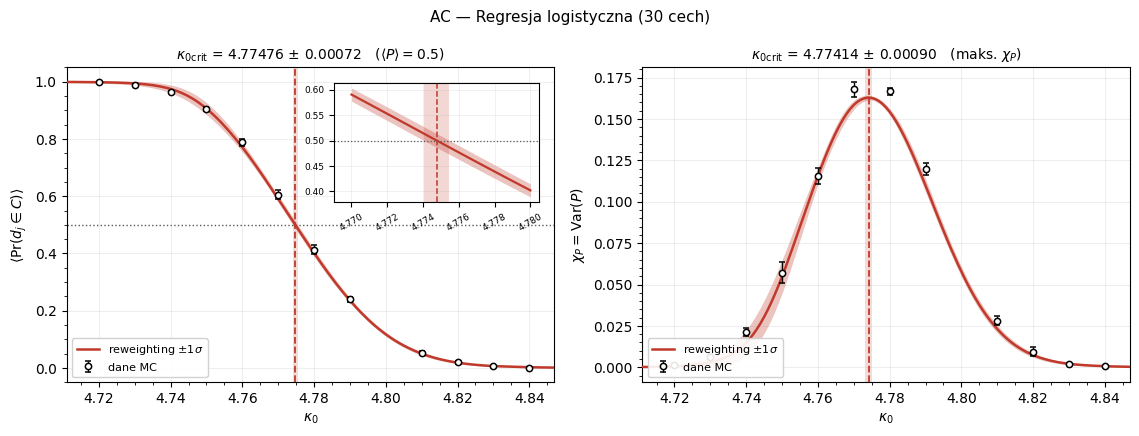

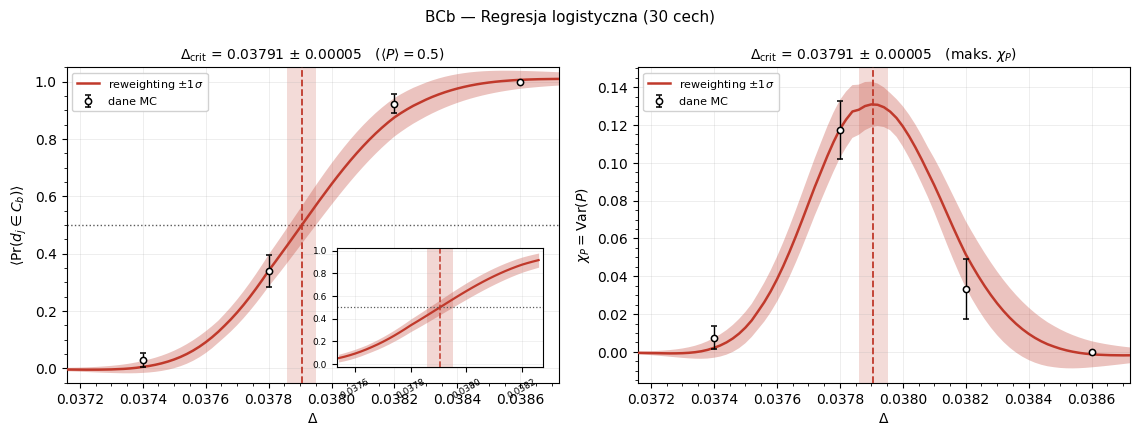

In [19]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def _ess_shade(ax, df):
    """Szare tło tam, gdzie reweighting przestaje być wiarygodny."""
    if not SHOW_ESS_SHADE:
        return
    ess = df.groupby("param")["ess_frac"].max().sort_index()
    ax.fill_between(ess.index.to_numpy(), 0, 1,
                    where=(ess.to_numpy() < ESS_MIN_FRAC),
                    transform=ax.get_xaxis_transform(),
                    color="0.85", alpha=0.6, lw=0, zorder=0)


def _free_corner(p, m, window):
    """Wolny róg panelu: krzywa rosnąca zajmuje prawy górny, malejąca - prawy dolny."""
    sel = (p >= window[0]) & (p <= window[1])
    if sel.sum() < 2:
        return "upper right"
    v = m[sel]
    k = max(1, len(v) // 5)
    rising = float(np.mean(v[-k:])) > float(np.mean(v[:k]))
    return "lower right" if rising else "upper right"


def plot_transition_detail(folder: str, tag: str = None, window=None,
                           inset_sigma: float = 8.0, inset_loc: str = "auto",
                           save=True):
    """Rysunek szczegółowy: <P> i chi_P dla jednego modelu, MC vs reweighting.

    inset_loc: "auto" dobiera róg wstawki do kierunku krzywej (dla AC z PLOT_FLIP
    krzywa maleje -> prawy górny, dla BCb rośnie -> prawy dolny). Można też podać
    wprost dowolną wartość loc z matplotlib, np. "lower left".
    """
    cfg = TRANSITIONS[folder]
    summary, mean_all, chi_all, out_dir = _read_results(folder)

    if tag is None:
        tag = PLOT_MODEL_TAG.get(folder, "LR")
        if tag not in set(summary["tag"]):
            tag = summary["tag"].iloc[0]
    row = summary[summary["tag"] == tag].iloc[0]

    mean_df = mean_all[mean_all["tag"] == tag].sort_values("param")
    chi_df = chi_all[chi_all["tag"] == tag].sort_values("param")
    label = param_label(row["param_key"])
    chi_col = row.get("chi_definition", CHI_FOR_PEAK)

    crit, crit_err = float(row["param_crit"]), float(row["param_crit_err"])
    peak, peak_err = float(row["chi_peak_param"]), float(row["chi_peak_err"])
    if window is None:
        window = transition_window(mean_df, crit)

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

    # ---------------- panel 1: <P> ----------------
    ax = axes[0]
    _ess_shade(ax, mean_df)
    p, m, e = (mean_df[c].to_numpy(float) for c in ("param", "mean", "mean_err"))
    ax.fill_between(p, m - e, m + e, color=C_BAND, alpha=0.30, lw=0, zorder=2)
    ax.plot(p, m, color=C_RW, lw=1.8, zorder=3, label=r"reweighting $\pm 1\sigma$")

    mc = load_mc_points(folder, row["model"], "mean", quiet=True)
    if mc is not None:
        ax.errorbar(mc["param"], mc["value"], yerr=mc["err"], fmt="o", ms=4.5,
                    color=C_MC, mfc="white", mew=1.1, lw=1, capsize=2.5, zorder=4,
                    label="dane MC")

    ax.axhline(0.5, color="0.35", ls=":", lw=1, zorder=1)
    if np.isfinite(crit_err):
        ax.axvspan(crit - crit_err, crit + crit_err, color=C_RW, alpha=0.18, lw=0, zorder=1)
    ax.axvline(crit, color=C_RW, ls="--", lw=1.3, zorder=3)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(prob_label(folder))
    ax.set_title(f"{label}$_{{\\rm crit}}$ = {crit:.5f} $\\pm$ {crit_err:.5f}   "
                 r"($\langle P \rangle = 0.5$)", fontsize=10)

    # ---------------- panel 2: podatność ----------------
    ax2 = axes[1]
    _ess_shade(ax2, chi_df)
    pc, c, ce = (chi_df[col].to_numpy(float) for col in ("param", chi_col, f"{chi_col}_err"))
    ax2.fill_between(pc, c - ce, c + ce, color=C_BAND, alpha=0.30, lw=0, zorder=2)
    ax2.plot(pc, c, color=C_RW, lw=1.8, zorder=3, label=r"reweighting $\pm 1\sigma$")

    # kolumna "chi" w plikach supervised to Var(P) -> pasuje do kolumny "variance"
    mc_chi = load_mc_points(folder, row["model"], "chi", quiet=True)
    if mc_chi is not None:
        ax2.errorbar(mc_chi["param"], mc_chi["value"], yerr=mc_chi["err"], fmt="o", ms=4.5,
                     color=C_MC, mfc="white", mew=1.1, lw=1, capsize=2.5, zorder=4,
                     label="dane MC")

    if np.isfinite(peak_err):
        ax2.axvspan(peak - peak_err, peak + peak_err, color=C_RW, alpha=0.18, lw=0, zorder=1)
    ax2.axvline(peak, color=C_RW, ls="--", lw=1.3, zorder=3)
    ax2.set_ylabel(r"$\chi_P = \mathrm{Var}(P)$")
    ax2.set_title(f"{label}$_{{\\rm crit}}$ = {peak:.5f} $\\pm$ {peak_err:.5f}   "
                  r"(maks. $\chi_P$)", fontsize=10)

    _corner = _free_corner(p, m, window) if inset_loc == "auto" else inset_loc
    leg_loc = "lower left" if "upper" in _corner else "upper left"

    for a in axes:
        a.set_xlim(*window)
        a.set_xlabel(label)
        a.grid(alpha=0.25, lw=0.6)
        a.minorticks_on()
        a.legend(fontsize=8, loc=leg_loc, framealpha=0.9)

    fig.suptitle(f"{cfg['tag']} — {model_label(row['model'])} ({N_FEATURES} cech)", fontsize=11)
    fig.tight_layout()

    # wstawka dopiero po tight_layout - inaczej matplotlib ostrzega, że nie potrafi
    # ułożyć osi wstawki i położenie panelu potrafi się rozjechać
    if np.isfinite(crit) and np.isfinite(crit_err) and crit_err > 0:
        half = inset_sigma * crit_err
        sel = (p >= crit - half) & (p <= crit + half)
        if sel.sum() >= 3:
            loc = _free_corner(p, m, window) if inset_loc == "auto" else inset_loc
            axi = inset_axes(axes[0], width="42%", height="38%",
                             loc=loc, borderpad=1.1)
            axi.fill_between(p[sel], (m - e)[sel], (m + e)[sel],
                             color=C_BAND, alpha=0.30, lw=0)
            axi.plot(p[sel], m[sel], color=C_RW, lw=1.6)
            axi.axhline(0.5, color="0.35", ls=":", lw=0.9)
            axi.axvspan(crit - crit_err, crit + crit_err, color=C_RW, alpha=0.20, lw=0)
            axi.axvline(crit, color=C_RW, ls="--", lw=1.1)
            axi.set_xlim(crit - half, crit + half)
            axi.tick_params(labelsize=6.5)
            axi.ticklabel_format(useOffset=False, style="plain", axis="x")
            for lbl in axi.get_xticklabels():
                lbl.set_rotation(30)
            axi.grid(alpha=0.25, lw=0.5)

    if save:
        _save(fig, out_dir, f"detail_{cfg['tag']}_{tag}")
    plt.show()


plot_transition_detail("c_a", "LR")
plot_transition_detail("b_cb", "LR")
# plot_transition_detail("a_b", "LR")

## 17. Interpolacja vs ponowne ważenie histogramów — rysunek zbiorczy i tabela

Porównanie dwóch dróg do punktu krytycznego, model po modelu, osobny panel na przejście:

* **interpolacja liniowa** między zmierzonymi punktami siatki (sekcja 5.2 pracy) —
  kolumny `K0_crit` / `K0_crit_err` z `AC_summary.csv`,
* **ponowne ważenie histogramów** — kolumny `param_crit` / `param_crit_err`
  z `reweighting_results/`.

### Skąd błąd średniej

Wartość po modelach obarczona jest **dwoma niezależnymi źródłami niepewności**:

| składowa | co mierzy | jak liczona |
|---|---|---|
| `err_stat` | błąd statystyczny pojedynczego modelu | średnia z `σ_i` jackknife'a |
| `err_model` | systematyka wyboru modelu | odchylenie standardowe wartości między modelami |
| `err_total` | łącznie | `sqrt(err_stat² + err_model²)` |

**`err_stat` celowo nie jest dzielone przez `√n`.** Wszystkie modele liczone są na tych
samych konfiguracjach Monte Carlo, więc ich błędy jackknife są niemal w pełni skorelowane
— uśrednienie po modelach nie zmniejsza błędu statystycznego, tak jak nie zmniejsza go
policzenie tej samej próbki dwa razy. Dzielenie przez `√n` dałoby tu niepewność zaniżoną
o czynnik rzędu `√7`.

Dla porównania raportowany jest też **zakres 1σ**, czyli `[min(v − σ), max(v + σ)]` po
wszystkich modelach. To definicja użyta w arXiv:2510.02159 (*„the error bars are defined
by the overall range of 1σ confidence intervals of the individual ML models"*) i to ją
należy zestawiać z wartościami z artykułu. Jest bardziej konserwatywna niż `err_total`,
bo zależy od skrajnych modeli, a nie od rozrzutu.

Uwaga przy czytaniu wykresu: zakres osi liczony jest **bez modeli odstających**
(`robust_keep`), bo inaczej jeden model z ogromnym słupkiem ściska pozostałe do
nierozróżnialnej kreski. Modele poza kadrem dostają strzałkę i są wypisywane pod
wykresem — tak jak modele bez wyznaczonego punktu krytycznego (`NaN`), gdzie pusty
wiersz zwykle znaczy, że krzywa `<P>` nigdy nie przecięła poziomu `0.5`.


[b_cb] tylko interpolacja (brak ponownego ważenia): NN


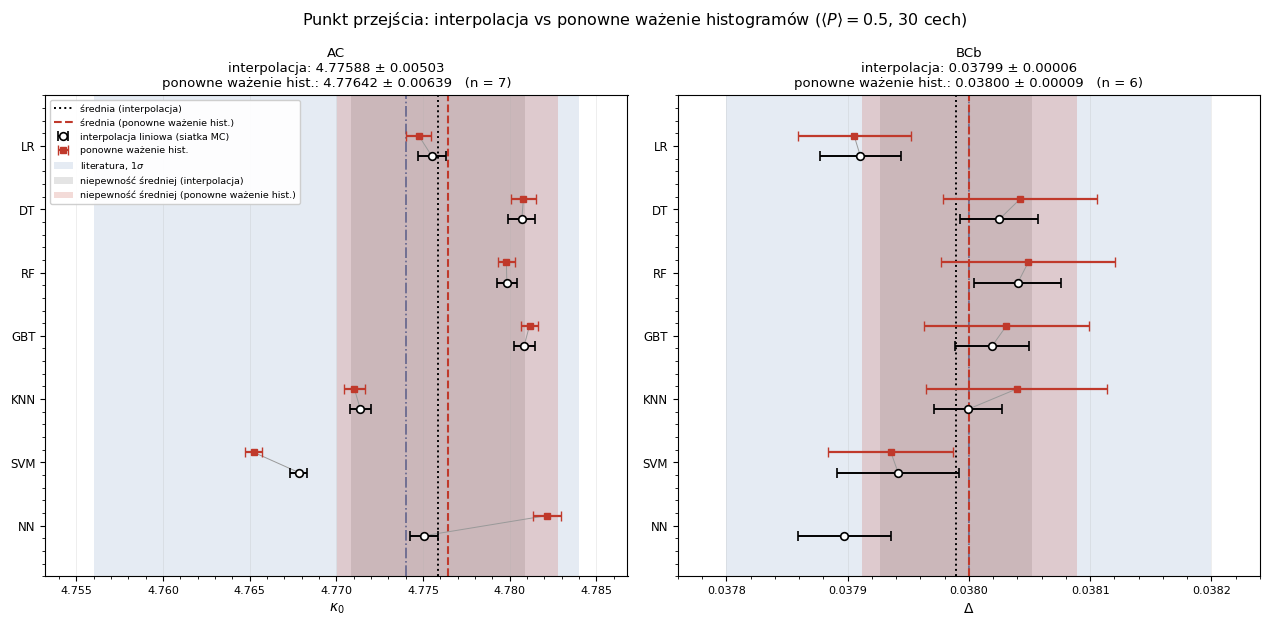


=== AC ===


,tag,model,interp,interp_err,rw,rw_err,n_sigma,zysk
0,LR,Regresja logistyczna,4.775509,0.000807,4.774761,0.000716,0.692829,1.127612
1,DT,Drzewo decyzyjne,4.780701,0.000786,4.780792,0.000730,0.085395,1.077309
2,RF,Las losowy,4.779837,0.000587,4.779812,0.000483,0.032998,1.215657
3,GBT,Wzmocnienie gradientowe,4.780832,0.000608,4.781146,0.000484,0.403786,1.256046
4,KNN,kNN,4.771386,0.000617,4.771042,0.000622,0.392443,0.991569
5,SVM,SVM (RBF),4.767836,0.000491,4.765222,0.000502,3.721577,0.978484
6,NN,Sieć neuronowa,4.775034,0.000814,4.782158,0.000793,6.271461,1.026509


modele w statystykach     : LR, DT, RF, GBT, KNN, SVM, NN
średnia |różnicy| w sigma : 1.66  (maks. 6.27)
średni zysk na precyzji   : 1.10 x  (zakres 0.98-1.26)
rozstęp wartości / typowy błąd : 27 x

=== BCb ===


,tag,model,interp,interp_err,rw,rw_err,n_sigma,zysk
0,LR,Regresja logistyczna,0.037911,0.000034,0.037905,0.000047,0.088842,0.721321
1,DT,Drzewo decyzyjne,0.038025,0.000032,0.038042,0.000064,0.241237,0.507661
2,RF,Las losowy,0.038040,0.000036,0.038049,0.000072,0.106692,0.500076
3,GBT,Wzmocnienie gradientowe,0.038019,0.000030,0.038031,0.000068,0.158467,0.443692
4,KNN,kNN,0.037999,0.000028,0.038039,0.000075,0.501571,0.374951
5,SVM,SVM (RBF),0.037942,0.000050,0.037936,0.000052,0.083245,0.972077
6,NN,Sieć neuronowa,0.037897,0.000038,NaN,NaN,NaN,NaN


modele w statystykach     : LR, DT, RF, GBT, KNN, SVM
średnia |różnicy| w sigma : 0.20  (maks. 0.50)
średni zysk na precyzji   : 0.59 x  (zakres 0.37-0.97)
rozstęp wartości / typowy błąd : 2 x
poza statystykami         : NN

=== statystyki po modelach (kryterium <P> = 0.5) ===


,przejscie,metoda,srednia,err_stat,err_model,err_total,zakres_lo,zakres_hi,n,szer_zakresu
0,AC,interpolacja,4.775876,0.000673,0.004986,0.005031,4.767345,4.781487,7,0.014142
1,AC,ponowne ważenie hist.,4.776419,0.000618,0.006363,0.006393,4.764720,4.782950,7,0.018230
2,BCb,interpolacja,0.037989,0.000035,0.000052,0.000062,0.037877,0.038076,6,0.000199
3,BCb,ponowne ważenie hist.,0.038000,0.000063,0.000063,0.000089,0.037859,0.038120,6,0.000262



=== statystyki po modelach (kryterium maksimum chi_P) ===


,przejscie,metoda,srednia,err_stat,err_model,err_total,zakres_lo,zakres_hi,n,szer_zakresu
0,AC,interpolacja,4.775876,0.000673,0.004986,0.005031,4.767345,4.781487,7,0.014142
1,AC,ponowne ważenie hist.,4.775890,0.000746,0.006612,0.006654,4.763387,4.783343,7,0.019956
2,BCb,interpolacja,0.037976,0.000035,0.000059,0.000068,0.037859,0.038076,7,0.000217
3,BCb,ponowne ważenie hist.,0.037952,0.000804,0.000108,0.000811,0.032501,0.042974,7,0.010473


In [20]:
"""Porównanie interpolacji liniowej z ponownym ważeniem histogramów.

Wymaga zdefiniowanych wcześniej w notatniku:
    np, pd, plt, display
    RW_DIR, TRANSITIONS, N_FEATURES, C_RW, MODEL_EXCLUDE
    _read_results(folder), _save(fig, dir, name)
    model_label(model), param_label(param_key), robust_keep(values, errors)

Zmiana względem wcześniejszej wersji: model, dla którego istnieje wynik
interpolacji, a nie istnieje wynik ponownego ważenia, pozostaje na wykresie
(rysowany jest sam punkt interpolacyjny). Decyzja "co rysujemy" jest odtąd
niezależna od decyzji "co wchodzi do średniej" -- tą drugą steruje wyłącznie
stats_keep().
"""

# =====================================================================
# KONFIGURACJA
# =====================================================================

RW_NAME = "ponowne ważenie hist."      # nazwa metody na wykresach i w tabelach

# Modele pomijane przy liczeniu STATYSTYK po modelach (średnia, zakres 1 sigma).
# Nie znikają z tabeli ani z wykresu - wyłączone są wyłącznie z uśredniania.
STATS_EXCLUDE = ()

# Czy średnie po modelach liczyć wyłącznie na modelach, dla których OBIE metody
# dały wynik.
#   True  - odtwarza tabelę 5.3 (n = 7 dla A-C, n = 6 dla B-Cb). Model bez wyniku
#           ponownego ważenia jest widoczny na wykresie, ale nie przesuwa średniej
#           z interpolacji, dzięki czemu obie średnie liczone są na tym samym
#           zbiorze modeli i można je uczciwie porównywać.
#   False - średnia z interpolacji korzysta także z modeli bez przewazania;
#           liczności n obu metod mogą się wtedy różnić.
STATS_REQUIRE_BOTH = True

# Stała kolejność wierszy na wykresie porównawczym. Bez tego każdy panel sortował
# się po własnym "rw" i ten sam model lądował w innej linii w AC i w BCb.
MODEL_ORDER = ["LR", "DT", "RF", "GBT", "KNN", "SVM", "NN"]


# =====================================================================
# NARZĘDZIA POMOCNICZE
# =====================================================================

def order_tags(tags) -> list:
    """Tagi w kolejności MODEL_ORDER; nieznane alfabetycznie na końcu."""
    tags = list(dict.fromkeys(tags))
    known = [t for t in MODEL_ORDER if t in tags]
    return known + sorted(set(tags) - set(known))


def _finite(series) -> "np.ndarray":
    """Maska wartości skończonych jako czysta tablica bool (bez indeksu pandas)."""
    return np.isfinite(pd.to_numeric(series, errors="coerce")).to_numpy()


def stats_keep(t, robust: bool = False):
    """Maska modeli wchodzących do statystyk po modelach.

    Składa się z trzech niezależnych warunków:
      1. robust=True dodatkowo odrzuca modele odstające wg robust_keep. UWAGA:
         skalą w robust_keep jest mediana błędów STATYSTYCZNYCH, więc gdy rozrzut
         międzymodelowy jest od niej wielokrotnie większy (dla A-C jest ~26x
         większy), kryterium odrzuca modele całkowicie poprawne - dla A-C wypadają
         wtedy SVM i GBT. Dlatego domyślnie robust=False.
      2. STATS_REQUIRE_BOTH wymaga wyniku obu metod (patrz opis stałej).
      3. STATS_EXCLUDE - jawna lista wykluczeń.
    """
    keep = (robust_keep(t["rw"], t["rw_err"]) if robust
            else np.ones(len(t), dtype=bool))
    keep = np.asarray(keep, dtype=bool)

    if STATS_REQUIRE_BOTH:
        keep &= _finite(t["rw"]) & _finite(t["interp"])
    if STATS_EXCLUDE:
        keep &= ~t["tag"].isin(STATS_EXCLUDE).to_numpy()
    return keep


def _fmt(value, err, nd=5):
    return f"{value:.{nd}f} ± {err:.{nd}f}"


# =====================================================================
# TABELE
# =====================================================================

def crit_table(folder: str, criterion: str = "crossing",
               apply_exclude: bool = True, sort_by: str = "tag") -> pd.DataFrame:
    """Zestawienie interpolacja vs ponowne ważenie histogramów dla jednego przejścia.

    criterion: "crossing" (<P> = 0.5) albo "peak" (maksimum chi_P).
    n_sigma = |różnica| / sqrt(sigma_interp^2 + sigma_rw^2)
    zysk    = sigma_interp / sigma_rw

    apply_exclude filtruje MODEL_EXCLUDE także na gotowych wynikach, więc nie trzeba
    przeliczać całego pipeline'u, żeby wyczyścić wykres ze zbędnych wariantów modeli.

    sort_by: "tag" -> stała kolejność MODEL_ORDER (do wykresu porównawczego),
             dowolna kolumna, np. "rw" -> sortowanie po wartości (do tabel w tekście).

    Zwracana tabela zachowuje wiersze z brakującym "rw" albo brakującym "interp" -
    odsiewanie należy do funkcji wywołującej.
    """
    summary, _, _, _ = _read_results(folder)

    if apply_exclude and MODEL_EXCLUDE:
        drop = (summary["model"].astype(str).str.lower()
                .str.contains(MODEL_EXCLUDE, regex=True, na=False).to_numpy(dtype=bool))
        summary = summary[~drop]

    val_col = "param_crit" if criterion == "crossing" else "chi_peak_param"
    err_col = "param_crit_err" if criterion == "crossing" else "chi_peak_err"

    t = pd.DataFrame({
        "tag": summary["tag"],
        "model": summary["model"].map(model_label),
        "interp": pd.to_numeric(summary.get("crit_interp"), errors="coerce"),
        "interp_err": pd.to_numeric(summary.get("crit_interp_err"), errors="coerce"),
        "rw": pd.to_numeric(summary[val_col], errors="coerce"),
        "rw_err": pd.to_numeric(summary[err_col], errors="coerce"),
    })

    t["diff"] = t["rw"] - t["interp"]

    denom = np.sqrt(t["interp_err"] ** 2 + t["rw_err"] ** 2)
    t["n_sigma"] = np.where(denom > 0, np.abs(t["diff"]) / denom, np.nan)

    # zerowy błąd interpolacji zdarza się dla przejścia A-B (funkcja schodkowa),
    # więc iloraz liczymy warunkowo, żeby nie produkować inf
    t["zysk"] = np.where(t["rw_err"] > 0, t["interp_err"] / t["rw_err"], np.nan)

    if sort_by == "tag":
        t = t.set_index("tag").reindex(order_tags(t["tag"])).reset_index()
    else:
        t = t.sort_values(sort_by)
    return t.reset_index(drop=True)


def _stats(values, errors, keep=None):
    """Średnia po modelach wraz z rozbiciem niepewności.

    err_stat  - błąd statystyczny: średnia z sigma_i jackknife'a. NIE dzielimy przez
                sqrt(n), bo wszystkie modele korzystają z tych samych konfiguracji MC
                i ich błędy są niemal w pełni skorelowane.
    err_model - systematyka wyboru modelu: odchylenie standardowe wartości.
    err_total - sqrt(err_stat^2 + err_model^2).
    zakres_lo/hi - [min(v - sigma), max(v + sigma)], definicja z arXiv:2510.02159.
    """
    v = np.asarray(values, float)
    e = np.asarray(errors, float)

    ok = np.isfinite(v)
    if keep is not None:
        ok &= np.asarray(keep, bool)

    if not ok.any():
        return dict(srednia=np.nan, err_stat=np.nan, err_model=np.nan, err_total=np.nan,
                    zakres_lo=np.nan, zakres_hi=np.nan, n=0)

    vv = v[ok]
    ee = np.where(np.isfinite(e[ok]), e[ok], 0.0)

    err_stat = float(np.mean(ee))
    err_model = float(np.std(vv, ddof=1)) if len(vv) > 1 else 0.0

    return dict(srednia=float(np.mean(vv)),
                err_stat=err_stat,
                err_model=err_model,
                err_total=float(np.hypot(err_stat, err_model)),
                zakres_lo=float(np.min(vv - ee)),
                zakres_hi=float(np.max(vv + ee)),
                n=int(len(vv)))


def crit_summary(folders=("c_a", "b_cb"), criterion: str = "crossing",
                 robust: bool = False) -> pd.DataFrame:
    """Statystyki po modelach: średnia z rozbiciem błędu + zakres 1 sigma.

    Do tabeli wchodzą modele mające wynik którejkolwiek z metod; o tym, które
    faktycznie wpływają na średnią, decyduje stats_keep (domyślnie: obie metody).

    Kolumna `n` mówi, ile modeli faktycznie weszło do średniej - warto ją podać
    w opisie tabeli, żeby wiersz "Średnia" nie wyglądał na średnią ze wszystkich
    wierszy powyżej.
    """
    if isinstance(folders, str):
        folders = (folders,)

    rows = []
    for folder in folders:
        if not (RW_DIR / folder / "summary.csv").exists():
            continue

        t = crit_table(folder, criterion)
        t = t[_finite(t["rw"]) | _finite(t["interp"])].reset_index(drop=True)
        if t.empty:
            continue

        keep = stats_keep(t, robust)
        for metoda, vc, ec in (("interpolacja", "interp", "interp_err"),
                               (RW_NAME, "rw", "rw_err")):
            s = _stats(t[vc], t[ec], keep)
            rows.append(dict(przejscie=TRANSITIONS[folder]["tag"], metoda=metoda, **s))

    out = pd.DataFrame(rows)
    if not out.empty:
        out["szer_zakresu"] = out["zakres_hi"] - out["zakres_lo"]
    return out


# =====================================================================
# WYKRES PORÓWNAWCZY
# =====================================================================

def _crit_panel(ax, folder, criterion, literature, robust_xlim, show_legend,
                row_order=None):
    """Jeden panel wykresu porównawczego.

    Zwraca (tabela, problemy, tylko_interpolacja), gdzie:
      problemy          - modele bez żadnego wyniku oraz modele poza skalą osi,
      tylko_interpolacja - modele narysowane wyłącznie punktem interpolacyjnym.

    row_order: wspólna dla wszystkich paneli lista tagów. Model bez wyniku w danym
    przejściu zostawia pustą linię, zamiast przesuwać pozostałe wiersze.
    """
    summary, _, _, _ = _read_results(folder)
    label = param_label(summary["param_key"].iloc[0])

    t = crit_table(folder, criterion)

    # --- klasyfikacja wierszy PRZED zawężeniem tabeli ----------------------------------
    has_rw = _finite(t["rw"])
    has_int = _finite(t["interp"])
    only_interp = sorted(t.loc[has_int & ~has_rw, "tag"])   # rysujemy, ale bez kwadratu
    no_result = sorted(t.loc[~has_int & ~has_rw, "tag"])    # nie ma czego rysować

    t = t[has_rw | has_int].reset_index(drop=True)
    if row_order is not None:
        t = t.set_index("tag").reindex(row_order).reset_index()

    # maski trzeba przeliczyć: reindex dołożył puste wiersze dla modeli
    # obecnych w innych przejściach
    has_rw = _finite(t["rw"])
    has_int = _finite(t["interp"])

    if t.empty or not (has_rw | has_int).any():
        ax.set_title(f"{TRANSITIONS[folder]['tag']} — brak wyników", fontsize=10)
        return t, no_result, only_interp

    keep = np.asarray(robust_keep(t["rw"], t["rw_err"]), bool) & has_rw  # tylko do osi
    keep_stats = stats_keep(t)                                          # do średnich
    st_rw = _stats(t["rw"], t["rw_err"], keep_stats)
    st_int = _stats(t["interp"], t["interp_err"], keep_stats)
    has_rw_stats = st_rw["n"] > 0
    has_int_stats = st_int["n"] > 0

    # --- pasma tła --------------------------------------------------------------------
    # Trzy pasma tła - każde opisane w legendzie, bo bez tego są nie do odróżnienia:
    #   niebieskie  - przedział 1 sigma z literatury,
    #   szare       - niepewność średniej z interpolacji,
    #   czerwone    - niepewność średniej z ponownego ważenia.
    if literature is not None:
        ax.axvspan(literature[0] - literature[1], literature[0] + literature[2],
                   color="#4c72b0", alpha=0.14, lw=0, zorder=0,
                   label=r"literatura, $1\sigma$")
        ax.axvline(literature[0], color="#4c72b0", ls="-.", lw=1.2, zorder=1)

    if has_int_stats:
        ax.axvspan(st_int["srednia"] - st_int["err_total"],
                   st_int["srednia"] + st_int["err_total"],
                   color="0.35", alpha=0.16, lw=0, zorder=1,
                   label="niepewność średniej (interpolacja)")
        ax.axvline(st_int["srednia"], color="black", ls=":", lw=1.4, zorder=2,
                   label="średnia (interpolacja)")

    if has_rw_stats:
        ax.axvspan(st_rw["srednia"] - st_rw["err_total"],
                   st_rw["srednia"] + st_rw["err_total"],
                   color=C_RW, alpha=0.18, lw=0, zorder=1,
                   label=f"niepewność średniej ({RW_NAME})")
        ax.axvline(st_rw["srednia"], color=C_RW, ls="--", lw=1.5, zorder=2,
                   label=f"średnia ({RW_NAME})")

    # --- punkty i łączniki ------------------------------------------------------------
    y = np.arange(len(t))
    for i in y:
        if has_int[i] and has_rw[i]:
            ax.plot([t.loc[i, "interp"], t.loc[i, "rw"]], [i + 0.16, i - 0.16],
                    color="0.6", lw=0.7, zorder=2)

    # NaN w xerr wywraca matplotlib, same NaN w danych są pomijane -
    # dzięki temu wiersz tylko-interpolacyjny rysuje kółko bez kwadratu
    ax.errorbar(t["interp"], y + 0.16, xerr=t["interp_err"].fillna(0.0), fmt="o", ms=5.5,
                color="black", mfc="white", mew=1.2, elinewidth=1.4, capsize=3.5,
                zorder=3, label="interpolacja liniowa (siatka MC)")
    ax.errorbar(t["rw"], y - 0.16, xerr=t["rw_err"].fillna(0.0), fmt="s", ms=5.0,
                color=C_RW, elinewidth=1.6, capsize=3.5,
                zorder=4, label=RW_NAME)

    # --- zakres osi liczony bez modeli odstających -------------------------------------
    outliers = []
    if robust_xlim:
        edges = [t.loc[keep, "rw"] - t.loc[keep, "rw_err"].fillna(0.0),
                 t.loc[keep, "rw"] + t.loc[keep, "rw_err"].fillna(0.0)]

        # wiersze tylko-interpolacyjne mają keep=False (bo rw jest NaN),
        # a mimo to muszą zmieścić się na osi
        ik = has_int & (keep | ~has_rw)
        if ik.any():
            edges += [t.loc[ik, "interp"] - t.loc[ik, "interp_err"].fillna(0.0),
                      t.loc[ik, "interp"] + t.loc[ik, "interp_err"].fillna(0.0)]

        if literature is not None:
            edges.append(pd.Series([literature[0] - literature[1],
                                    literature[0] + literature[2]]))

        v = pd.concat(edges).to_numpy(float)
        v = v[np.isfinite(v)]
        if v.size:
            lo, hi = float(v.min()), float(v.max())
            pad = 0.10 * max(hi - lo, 1e-12)
            ax.set_xlim(lo - pad, hi + pad)

        x0, x1 = ax.get_xlim()
        for i in y:
            val = t.loc[i, "rw"]
            if not np.isfinite(val):         # pusta linia albo sama interpolacja
                continue
            if not (x0 <= val <= x1):
                outliers.append(t.loc[i, "tag"])
                side = 0.985 if val > x1 else 0.015
                ax.annotate("→" if val > x1 else "←",
                            xy=(side, i), xycoords=("axes fraction", "data"),
                            fontsize=11, color=C_RW, ha="center", va="center", zorder=6)

    # --- opis osi ---------------------------------------------------------------------
    ax.set_yticks(y)
    ax.set_yticklabels(t["tag"], fontsize=8.5)
    ax.set_ylim(-0.8, len(t) - 0.2)
    ax.invert_yaxis()
    ax.set_xlabel(label)
    ax.grid(axis="x", alpha=0.25, lw=0.6)
    ax.minorticks_on()
    ax.tick_params(axis="x", labelsize=8)

    # --- tytuł panelu -----------------------------------------------------------------
    ref_err = st_rw["err_total"] if has_rw_stats else st_int["err_total"]
    nd = 5 if (np.isfinite(ref_err) and ref_err > 1e-5) else 6

    lines = [TRANSITIONS[folder]["tag"]]
    if has_int_stats:
        line = f"interpolacja: {_fmt(st_int['srednia'], st_int['err_total'], nd)}"
        if st_int["n"] != st_rw["n"]:        # różne liczności -> podaj obie jawnie
            line += f"   (n = {st_int['n']})"
        lines.append(line)
    if has_rw_stats:
        lines.append(f"{RW_NAME}: {_fmt(st_rw['srednia'], st_rw['err_total'], nd)}"
                     f"   (n = {st_rw['n']})")
    ax.set_title("\n".join(lines), fontsize=9.5)

    if show_legend:
        h, l = ax.get_legend_handles_labels()
        order = ([i for i, s in enumerate(l) if "niepewność" not in s and "literatura" not in s]
                 + [i for i, s in enumerate(l) if "niepewność" in s or "literatura" in s])
        ax.legend([h[i] for i in order], [l[i] for i in order],
                  fontsize=6.8, loc="upper left", framealpha=0.94)

    return t, no_result + outliers, only_interp


def plot_crit_comparison(folders=("c_a", "b_cb"), criterion="crossing",
                         literature=None, robust_xlim=True, save=True):
    """Interpolacja vs ponowne ważenie histogramów, jeden panel na przejście.

    literature: słownik {folder: (wartość, err_dolny, err_górny)}, np.
                {"c_a": (4.774, 0.018, 0.010), "b_cb": (0.0380, 0.0002, 0.0002)}

    Pionowe linie to średnie po modelach, pasma wokół nich to +- err_total
    (błąd statystyczny i systematyka wyboru modelu dodane w kwadraturze).

    Wiersze mają wspólną kolejność (MODEL_ORDER) we wszystkich panelach, więc ten
    sam model jest zawsze w tej samej linii. Model mający wyłącznie wynik
    interpolacji jest rysowany samym kółkiem.
    """
    if isinstance(folders, str):
        folders = (folders,)
    folders = [f for f in folders if (RW_DIR / f / "summary.csv").exists()]
    if not folders:
        print("brak wyników dla podanych przejść")
        return {}

    literature = literature or {}
    n = len(folders)

    # wspólna lista wierszy: wszystkie tagi występujące w którymkolwiek przejściu
    row_order = order_tags([tag for f in folders
                            for tag in crit_table(f, criterion)["tag"]])

    fig, axes = plt.subplots(1, n, figsize=(6.4 * n, 0.42 * len(row_order) + 3.4))
    axes = np.atleast_1d(axes)

    tables = {}
    for k, (ax, folder) in enumerate(zip(axes, folders)):
        t, problems, only_interp = _crit_panel(
            ax, folder, criterion, literature.get(folder),
            robust_xlim, show_legend=(k == 0), row_order=row_order)
        tables[folder] = t

        if only_interp:
            print(f"[{folder}] tylko interpolacja (brak ponownego ważenia): "
                  f"{', '.join(only_interp)}")
        if problems:
            print(f"[{folder}] bez wyniku lub poza skalą: {', '.join(problems)}")

    crit_name = (r"$\langle P \rangle = 0.5$" if criterion == "crossing"
                 else r"maksimum $\chi_P$")
    fig.suptitle(f"Punkt przejścia: interpolacja vs ponowne ważenie histogramów "
                 f"({crit_name}, {N_FEATURES} cech)", fontsize=11.5)
    fig.tight_layout()

    if save:
        for folder in folders:
            _save(fig, RW_DIR / folder, f"compare_{criterion}")
    plt.show()
    return tables


# =====================================================================
# WYWOŁANIE
# =====================================================================

tables = plot_crit_comparison(
    ("c_a", "b_cb"), "crossing",
    literature={"c_a": (4.774, 0.018, 0.010),
                "b_cb": (0.0380, 0.0002, 0.0002)},
)

for folder, t in tables.items():
    t = t[_finite(t["rw"]) | _finite(t["interp"])].reset_index(drop=True)
    print(f"\n=== {TRANSITIONS[folder]['tag']} ===")
    display(t[["tag", "model", "interp", "interp_err", "rw", "rw_err",
               "n_sigma", "zysk"]].round(6))

    _m = stats_keep(t)
    if not _m.any():
        print("brak modeli spełniających kryteria statystyk")
        continue

    _s = t.loc[_m]
    print(f"modele w statystykach     : {', '.join(_s['tag'])}")
    print(f"średnia |różnicy| w sigma : {_s['n_sigma'].mean():.2f}"
          f"  (maks. {_s['n_sigma'].max():.2f})")
    print(f"średni zysk na precyzji   : {_s['zysk'].mean():.2f} x"
          f"  (zakres {_s['zysk'].min():.2f}-{_s['zysk'].max():.2f})")
    print(f"rozstęp wartości / typowy błąd : "
          f"{(_s['rw'].max() - _s['rw'].min()) / _s['rw_err'].mean():.0f} x")

    # modele widoczne na wykresie, ale poza średnimi
    _out = t.loc[~_m & (_finite(t["rw"]) | _finite(t["interp"])), "tag"].tolist()
    if _out:
        print(f"poza statystykami         : {', '.join(_out)}")

for _crit, _opis in (("crossing", "<P> = 0.5"), ("peak", "maksimum chi_P")):
    print(f"\n=== statystyki po modelach (kryterium {_opis}) ===")
    display(crit_summary(("c_a", "b_cb"), _crit).round(6))

## 18. Diagnostyka: modele zdegenerowane

Płaska krzywa `<P>` po reweightingu prawie zawsze oznacza, że **model zwrócił niemal stałe
`P(d_j)`**, a nie że coś jest nie tak z samym reweightingiem. Jeśli `P` jest stałe, to
`<P>` jest tą samą stałą dla każdej wartości parametru (wagi się skracają), `Var(P) ≈ 0`,
a przecięcia z `0.5` nie ma wcale — stąd puste wiersze na wykresie zbiorczym.

Najczęstsza przyczyna w tym pipelinie to **brak standaryzacji przy sieci neuronowej**.
Cechy mają rzędy `10⁴`–`10⁵`, więc `MLPClassifier` bez skalowania saturuje się i zwraca
wartości przyklejone do `0` albo `1`. Pokrywa się to z sekcją 5.4 pracy, gdzie
standaryzacja zmieniła wynik **wyłącznie** dla sieci neuronowej i **właśnie dla
przejścia B–C_b**.

Poniższa komórka sprawdza dla każdego modelu:

* `std(P)` i udział `P` w przedziale `(0.01, 0.99)` — czy model w ogóle różnicuje konfiguracje,
* `train_acc` — czy nauczył się klasyfikacji (wartość ok. `0.5` to poziom losowy),
* `zakres <P>` po siatce — czy krzywa faktycznie przechodzi przez przejście.


In [21]:
def check_models(folder: str, flat_tol: float = 0.20, verbose: bool = True) -> pd.DataFrame:
    """Wykrywa modele o zdegenerowanym P(d_j) (płaska krzywa, brak punktu krytycznego)."""
    summary, mean_all, _, out_dir = _read_results(folder)
    index_path = out_dir / "probabilities_index.csv"
    index = pd.read_csv(index_path) if index_path.exists() else pd.DataFrame()

    rows = []
    for _, r in summary.iterrows():
        g = mean_all[mean_all["tag"] == r["tag"]]
        span = float(g["mean"].max() - g["mean"].min()) if not g.empty else np.nan

        std_P, frac_mid = np.nan, np.nan
        if not index.empty:
            hit = index[index["tag"] == r["tag"]]
            if not hit.empty:
                f = PROB_DIR / hit.iloc[0]["prob_file"]
                if f.exists():
                    Pv = np.loadtxt(f)
                    std_P = float(Pv.std())
                    frac_mid = float(np.mean((Pv > 0.01) & (Pv < 0.99)))

        problems = []
        if not np.isfinite(r["param_crit"]):
            problems.append("brak przecięcia z 0.5")
        if np.isfinite(span) and span < flat_tol:
            problems.append(f"płaska krzywa (zakres {span:.3f})")
        if np.isfinite(std_P) and std_P < 0.01:
            problems.append(f"stałe P (std {std_P:.4f})")
        if np.isfinite(r.get("train_acc", np.nan)) and r["train_acc"] < 0.9:
            problems.append(f"niska train_acc ({r['train_acc']:.3f})")

        rows.append(dict(tag=r["tag"], model=r["model"],
                         train_acc=r.get("train_acc", np.nan),
                         mean_at_close=r.get("mean_at_close", np.nan),
                         std_P=std_P, frac_mid=frac_mid, span_mean=span,
                         param_crit=r["param_crit"],
                         status="OK" if not problems else "; ".join(problems)))

    t = pd.DataFrame(rows)

    if verbose:
        bad = t[t["status"] != "OK"]
        print(f"[{TRANSITIONS[folder]['tag']}] modeli: {len(t)}, "
              f"podejrzanych: {len(bad)}")
        for _, r in bad.iterrows():
            print(f"   {r['tag']:14s} {r['status']}")
        if bad.empty:
            print("   wszystkie modele wyglądają poprawnie")
    return t


for _folder in TRANSITIONS_TO_RUN:
    if (RW_DIR / _folder / "summary.csv").exists():
        display(check_models(_folder).round(4))


[AC] modeli: 7, podejrzanych: 0
   wszystkie modele wyglądają poprawnie


,tag,model,train_acc,mean_at_close,std_P,frac_mid,span_mean,param_crit,status
0,LR,Logistic Regression,1.0,0.5982,0.3927,0.7026,0.9999,4.7748,OK
1,DT,Decision Tree,1.0,0.4866,0.4998,0.0000,1.0013,4.7808,OK
2,RF,Random Forest,1.0,0.5035,0.2751,0.9424,1.0001,4.7798,OK
3,GBT,Gradient Boosted Trees,1.0,0.4682,0.4545,0.4364,1.0000,4.7811,OK
4,KNN,kNN,1.0,0.4720,0.4489,0.2454,1.0000,4.7710,OK
5,SVM,SVM (RBF),1.0,0.5818,0.2314,0.9996,0.9576,4.7652,OK
6,NN,Neural Network,1.0,0.4682,0.3377,0.7021,0.9988,4.7822,OK


[BCb] modeli: 7, podejrzanych: 1
   NN             brak przecięcia z 0.5; płaska krzywa (zakres 0.000); stałe P (std 0.0000)


,tag,model,train_acc,mean_at_close,std_P,frac_mid,span_mean,param_crit,status
0,LR,Logistic Regression,1.0,0.3407,0.3392,0.8408,1.0144,0.0379,OK
1,DT,Decision Tree,1.0,0.8043,0.3968,0.0000,1.0211,0.0380,OK
2,RF,Random Forest,1.0,0.6547,0.1751,0.9998,0.9546,0.0380,OK
3,GBT,Gradient Boosted Trees,1.0,0.8204,0.3394,0.7932,1.0180,0.0380,OK
4,KNN,kNN,1.0,0.1396,0.3336,0.0430,1.0177,0.0380,OK
5,SVM,SVM (RBF),1.0,0.3509,0.2360,0.9986,1.0225,0.0379,OK
6,NN,Neural Network,1.0,0.9999,0.0000,0.0000,0.0000,NaN,brak przecięcia z 0.5; płaska krzywa (zakres 0...


In [22]:
# =========================================================================================

def _pm(v, e, nd):
    """4.774758, 0.000723 -> '$4.77476 \\pm 0.00072$'; NaN -> '---'."""
    if not np.isfinite(v):
        return "---"
    if not np.isfinite(e):
        return f"${v:.{nd}f}$"
    return f"${v:.{nd}f} \\pm {e:.{nd}f}$"


def latex_crit_table(folders=("c_a", "b_cb"), criterion="crossing", decimals=None):
    """Wiersze tabeli LaTeX: model | interpolacja | ponowne ważenie, dla obu przejść.

    decimals: słownik {folder: liczba miejsc}, domyślnie 5 dla K0 i 5 dla Delta.
    Kolejność modeli ustalona (jak w pracy), nie wg wartości.
    """
    decimals = decimals or {"c_a": 5, "b_cb": 5}
    order = ["LR", "DT", "RF", "GBT", "KNN", "SVM", "NN"]

    tabs = {}
    for f in folders:
        if (RW_DIR / f / "summary.csv").exists():
            tabs[f] = crit_table(f, criterion).set_index("tag")

    print("% --- wiersze do tab:crit-30 (kryterium: "
          f"{'<P> = 0.5' if criterion == 'crossing' else 'maksimum chi_P'}) ---")

    for tag in order:
        cells = []
        pl = None
        for f in folders:
            t = tabs.get(f)
            nd = decimals.get(f, 5)
            if t is None or tag not in t.index:
                cells += ["---", "---"]
                continue
            r = t.loc[tag]
            pl = pl or r["model"]
            cells += [_pm(r["interp"], r["interp_err"], nd),
                      _pm(r["rw"], r["rw_err"], nd)]
        if pl is None:
            continue
        print(f"{pl:24s} & " + " & ".join(cells) + r" \\")

    # wiersz ze średnimi
    s = crit_summary(folders, criterion)
    cells = []
    for f in folders:
        nd = decimals.get(f, 5)
        sub = s[s["przejscie"] == TRANSITIONS[f]["tag"]]
        for metoda in ("interpolacja", RW_NAME):
            row = sub[sub["metoda"] == metoda]
            cells.append(_pm(float(row["srednia"].iloc[0]),
                             float(row["err_total"].iloc[0]), nd)
                         if not row.empty else "---")
    print(r"\midrule")
    print(r"\textbf{Średnia}          & " + " & ".join(cells) + r" \\")

    # liczby do tekstu wniosków
    print("\n% --- liczby do akapitu o precyzji ---")
    for f in folders:
        if f not in tabs:
            continue
        sub = s[s["przejscie"] == TRANSITIONS[f]["tag"]]
        for metoda in ("interpolacja", RW_NAME):
            row = sub[sub["metoda"] == metoda]
            if row.empty:
                continue
            r = row.iloc[0]
            print(f"%   {TRANSITIONS[f]['tag']:4s} {metoda:22s}: "
                  f"err_stat={r['err_stat']:.5f}  err_model={r['err_model']:.5f}  "
                  f"err_total={r['err_total']:.5f}  zakres 1σ=[{r['zakres_lo']:.5f}, "
                  f"{r['zakres_hi']:.5f}]")
        t = tabs[f]
        print(f"%   {TRANSITIONS[f]['tag']:4s} zysk na precyzji (średnia po modelach): "
              f"{float(t['zysk'].mean()):.1f}x, mediana {float(t['zysk'].median()):.1f}x")


latex_crit_table(("c_a", "b_cb"), "crossing")
def latex_range_row(folders=("c_a", "b_cb"), criterion="crossing", nd=5):
    """Wiersz 'Zakres 1 sigma' prosto z crit_summary - te same liczby co w tytule wykresu."""
    s = crit_summary(folders, criterion).set_index(["przejscie", "metoda"])
    cells = []
    for folder in folders:
        for metoda in ("interpolacja", RW_NAME):
            r = s.loc[(TRANSITIONS[folder]["tag"], metoda)]
            cells.append(f"$[{r['zakres_lo']:.{nd}f},\\,{r['zakres_hi']:.{nd}f}]$"
                         if np.isfinite(r["zakres_lo"]) else "---")
    return r"\textbf{Zakres $1\sigma$} & " + " & ".join(cells) + r" \\"


print(latex_range_row())

% --- wiersze do tab:crit-30 (kryterium: <P> = 0.5) ---
Regresja logistyczna     & $4.77551 \pm 0.00081$ & $4.77476 \pm 0.00072$ & $0.03791 \pm 0.00003$ & $0.03791 \pm 0.00005$ \\
Drzewo decyzyjne         & $4.78070 \pm 0.00079$ & $4.78079 \pm 0.00073$ & $0.03802 \pm 0.00003$ & $0.03804 \pm 0.00006$ \\
Las losowy               & $4.77984 \pm 0.00059$ & $4.77981 \pm 0.00048$ & $0.03804 \pm 0.00004$ & $0.03805 \pm 0.00007$ \\
Wzmocnienie gradientowe  & $4.78083 \pm 0.00061$ & $4.78115 \pm 0.00048$ & $0.03802 \pm 0.00003$ & $0.03803 \pm 0.00007$ \\
kNN                      & $4.77139 \pm 0.00062$ & $4.77104 \pm 0.00062$ & $0.03800 \pm 0.00003$ & $0.03804 \pm 0.00007$ \\
SVM (RBF)                & $4.76784 \pm 0.00049$ & $4.76522 \pm 0.00050$ & $0.03794 \pm 0.00005$ & $0.03794 \pm 0.00005$ \\
Sieć neuronowa           & $4.77503 \pm 0.00081$ & $4.78216 \pm 0.00079$ & $0.03790 \pm 0.00004$ & --- \\
\midrule
\textbf{Średnia}          & $4.77588 \pm 0.00503$ & $4.77642 \pm 0.00639$ & $0.03799 